## SECTION 1: Project Setup & Environment

### 1.1 Library Installation

We begin by installing all necessary Python libraries with specific version pins to ensure reproducibility across environments and over time. This helps avoid compatibility issues that might arise with future library updates.

In [1]:
%%capture
import os, sys, subprocess
# Install project dependencies pinned in requirements.txt (compatible with
# Python 3.14). The earlier Colab-era pins (sklearn 1.4, evidently 0.4, ...)
# do not build on 3.14. Search likely locations so the cell works whether the
# notebook is run from the repo root or the notebooks/ subfolder.
for _req in ("requirements.txt", "../requirements.txt"):
    if os.path.exists(_req):
        subprocess.run([sys.executable, "-m", "pip", "install", "-r", _req], check=False)
        break



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


### 1.2 Reproducibility & Core Imports

To ensure our results are consistent, we'll set random seeds for all relevant libraries. We also import essential modules required for the initial setup.

In [2]:
import os
import random
import numpy as np
import pandas as pd
import logging
from dataclasses import dataclass, field

# Scikit-learn, XGBoost and other libraries will be imported as needed in subsequent sections.

def set_seeds(seed_value: int = 42):
    """Set random seeds for reproducibility across various libraries."""
    os.environ['PYTHONHASHSEED'] = str(seed_value)
    random.seed(seed_value)
    np.random.seed(seed_value)
    # These are for scikit-learn, but also good practice for any library using np.random
    # Note: Specific library seeds (like for XGBoost) will be set when the model is initialized.
    print(f"All random seeds set to {seed_value}.")

set_seeds()


All random seeds set to 42.


### 1.3 Project Directory Setup

We'll create a standard project directory structure to organize models, reports, and processed data. This helps maintain a clean and scalable project.

In [3]:
def create_project_directories(base_path: str = "."):
    """Create standard project directories if they don't exist."""
    dirs = {
        "models": os.path.join(base_path, "models"),
        "reports": os.path.join(base_path, "reports"),
        "data": os.path.join(base_path, "data")
    }
    for name, path in dirs.items():
        os.makedirs(path, exist_ok=True)
        print(f"Created directory: {path}")
    return dirs

PROJECT_DIRS = create_project_directories()


Created directory: ./models
Created directory: ./reports
Created directory: ./data


### 1.4 Centralized Configuration

All critical parameters, hyperparameters, thresholds, and paths will be stored in a single `CONFIG` dataclass. This prevents hardcoding and makes the project easier to manage and modify.

In [4]:
@dataclass(frozen=True)
class Config:
    """Centralized configuration for the Responsible AI project."""
    RANDOM_SEED: int = 42
    RISK_THRESHOLD: float = 10000.0  # Charges > 10000 = Bad Risk

    # Data Ingestion
    DATA_SOURCE: str = "URL" # Options: "URL", "KAGGLE"
    URL_DATA_PATH: str = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
    KAGGLE_SLUG: str = "harshsingh2209/medical-insurance-payout"
    KAGGLE_USERNAME_SECRET: str = "KAGGLE_USERNAME"
    KAGGLE_KEY_SECRET: str = "KAGGLE_KEY"
    EXPECTED_COLUMNS: list = field(default_factory=lambda: [
        'age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'
    ])

    # Project Directories
    MODELS_DIR: str = PROJECT_DIRS["models"]
    REPORTS_DIR: str = PROJECT_DIRS["reports"]
    DATA_DIR: str = PROJECT_DIRS["data"]

    # Logging
    LOG_FILE_PATH: str = os.path.join(PROJECT_DIRS["reports"], "project_log.log")
    LOG_LEVEL: int = logging.INFO

    # Preprocessing parameters
    TEST_SIZE: float = 0.2
    VAL_SIZE: float = 0.25 # Of the remaining train_val set (0.8 * 0.25 = 0.2 of total)
    TARGET_COLUMN: str = "risk_level"
    ORIGINAL_TARGET_COLUMN: str = "charges"

    # Model parameters will be added in Section 4

CONFIG = Config()

# Set seeds again using the CONFIG value
set_seeds(CONFIG.RANDOM_SEED)


All random seeds set to 42.


### 1.5 Python Logging Setup

Instead of `print()` statements, we'll configure Python's `logging` module for better control over messages, including severity levels and output destinations.

In [5]:
def setup_logging(log_file: str, log_level: int = logging.INFO):
    """Configure logging to file and console."""
    logging.basicConfig(
        level=log_level,
        format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
        handlers=[
            logging.FileHandler(log_file),
            logging.StreamHandler()
        ]
    )
    # Set a custom name for our project logger
    logger = logging.getLogger('ResponsibleAI_Project')
    logger.info(f"Logging configured. Messages will be saved to {log_file}")
    return logger

logger = setup_logging(CONFIG.LOG_FILE_PATH, CONFIG.LOG_LEVEL)
logger.info("Project setup initiated.")


2026-06-17 12:31:38,261 - ResponsibleAI_Project - INFO - Logging configured. Messages will be saved to ./reports/project_log.log


2026-06-17 12:31:38,261 - ResponsibleAI_Project - INFO - Project setup initiated.


### 1.6 Data Ingestion with Toggle and Verification

We'll implement a flexible data ingestion method with a toggle (`DATA_SOURCE`) to switch between direct URL loading (for immediate reproducibility) and Kaggle API (for authenticated access). After loading, a strict schema verification and basic sanity checks are performed.

In [6]:
try:
    from google.colab import userdata  # Kaggle credentials in Colab
except ImportError:
    userdata = None  # Running outside Colab; creds come from env or ~/.kaggle/kaggle.json

def load_data(config: Config) -> pd.DataFrame:
    """Load medical insurance data based on the configured source."""
    df = None
    if config.DATA_SOURCE == "URL":
        logger.info(f"Loading data from URL: {config.URL_DATA_PATH}")
        try:
            df = pd.read_csv(config.URL_DATA_PATH)
            logger.info("Data loaded successfully from URL.")
        except Exception as e:
            logger.error(f"Error loading data from URL: {e}")
            raise
    elif config.DATA_SOURCE == "KAGGLE":
        logger.info(f"Loading data from Kaggle dataset: {config.KAGGLE_SLUG}")
        try:
            # In Colab, read creds from secrets. Locally, rely on existing
            # KAGGLE_USERNAME/KAGGLE_KEY env vars or ~/.kaggle/kaggle.json.
            if userdata is not None:
                os.environ['KAGGLE_USERNAME'] = userdata.get(config.KAGGLE_USERNAME_SECRET)
                os.environ['KAGGLE_KEY'] = userdata.get(config.KAGGLE_KEY_SECRET)
            import kaggle
            # Download dataset
            dataset_path = os.path.join(config.DATA_DIR, config.KAGGLE_SLUG.split('/')[-1])
            kaggle.api.dataset_download_files(config.KAGGLE_SLUG, path=dataset_path, unzip=True)
            # Assuming the CSV is directly in the unzipped folder, or named consistently
            csv_files = [f for f in os.listdir(dataset_path) if f.endswith('.csv')]
            if not csv_files:
                raise FileNotFoundError("No CSV file found in the Kaggle dataset.")
            df = pd.read_csv(os.path.join(dataset_path, csv_files[0]))
            logger.info("Data loaded successfully from Kaggle.")
        except Exception as e:
            logger.error(f"Error loading data from Kaggle: {e}")
            logger.warning("To use Kaggle, set `KAGGLE_USERNAME` and `KAGGLE_KEY` (Colab secrets, env vars, or ~/.kaggle/kaggle.json).")
            raise
    else:
        raise ValueError(f"Invalid DATA_SOURCE: {config.DATA_SOURCE}. Must be 'URL' or 'KAGGLE'.")

    # Schema Verification
    current_columns = set(df.columns)
    expected_columns = set(config.EXPECTED_COLUMNS)
    try:
        assert current_columns == expected_columns, \
            f"Schema mismatch! Expected {expected_columns}, got {current_columns}"
        logger.info("Data schema verified successfully.")
    except AssertionError as e:
        logger.error(f"Schema verification failed: {e}")
        raise

    # Basic Sanity Checks
    if df.isnull().sum().sum() > 0:
        logger.warning("Dataset contains null values. This will be addressed in data engineering.")
    if df.duplicated().sum() > 0:
        logger.warning(f"Dataset contains {df.duplicated().sum()} duplicate rows. These will be handled.")

    logger.info(f"Initial data loaded with {df.shape[0]} rows and {df.shape[1]} columns.")
    logger.info("Displaying first 5 rows of the loaded data:")
    display(df.head())

    return df

try:
    raw_df = load_data(CONFIG)
except Exception as e:
    logger.critical(f"Failed to load initial data: {e}")
    raw_df = None # Set to None to prevent further execution without data


2026-06-17 12:31:38,266 - ResponsibleAI_Project - INFO - Loading data from URL: https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv


2026-06-17 12:31:38,317 - ResponsibleAI_Project - INFO - Data loaded successfully from URL.


2026-06-17 12:31:38,317 - ResponsibleAI_Project - INFO - Data schema verified successfully.


2026-06-17 12:31:38,325 - ResponsibleAI_Project - WARNING - Dataset contains 1 duplicate rows. These will be handled.


2026-06-17 12:31:38,325 - ResponsibleAI_Project - INFO - Initial data loaded with 1338 rows and 7 columns.


2026-06-17 12:31:38,325 - ResponsibleAI_Project - INFO - Displaying first 5 rows of the loaded data:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Observation

The data has been successfully loaded from the URL, and its schema has been verified against the expected columns. Initial checks indicate that the dataset might contain null values or duplicate rows, which will be addressed in the data engineering phase. The first 5 rows are displayed, confirming the correct structure.

### Next Step

Please run this section and confirm that all cells execute without errors. Once confirmed, we can proceed to 'SECTION 2: Data Engineering & EDA'.

## SECTION 2: Data Engineering & EDA

### 2.1 Data Validation & Initial Preprocessing

Before diving into EDA, we'll perform a thorough data validation step to check for nulls, incorrect data types, and out-of-range values. We'll also convert the `charges` target to a binary `risk_level` based on the defined threshold.

In [7]:
logger.info("Starting Data Validation and initial preprocessing.")

if raw_df is None:
    logger.critical("Raw data is not available. Cannot proceed with Data Engineering.")
    # Exit or provide alternative handling if data loading failed
else:
    df = raw_df.copy()

    # 1. Convert 'charges' to binary 'risk_level'
    df[CONFIG.TARGET_COLUMN] = (df[CONFIG.ORIGINAL_TARGET_COLUMN] > CONFIG.RISK_THRESHOLD).astype(int)
    logger.info(f"Converted '{CONFIG.ORIGINAL_TARGET_COLUMN}' to binary '{CONFIG.TARGET_COLUMN}' using threshold > {CONFIG.RISK_THRESHOLD}.")
    logger.info(f"'Bad Risk' (1) count: {df[CONFIG.TARGET_COLUMN].sum()}, 'Good Risk' (0) count: {len(df) - df[CONFIG.TARGET_COLUMN].sum()}")

    # 2. Check for Nulls
    null_counts = df.isnull().sum()
    if null_counts.sum() > 0:
        logger.warning(f"Found null values in columns:\n{null_counts[null_counts > 0]}")
        # For this dataset, we expect no nulls after initial load, if any, we'd impute or drop.
        # For now, we'll just assert there are none, as the dataset is clean.
        # assert null_counts.sum() == 0, "Null values detected, please handle them."
    else:
        logger.info("No null values found in the dataset.")

    # 3. Check for Duplicates
    initial_rows = df.shape[0]
    df.drop_duplicates(inplace=True)
    duplicates_removed = initial_rows - df.shape[0]
    if duplicates_removed > 0:
        logger.warning(f"Removed {duplicates_removed} duplicate rows.")
    else:
        logger.info("No duplicate rows found.")

    # 4. Check Data Types
    logger.info("Data types:")
    logger.info(f"\n{df.dtypes}")
    # Expected dtypes: age (int), sex (object), bmi (float), children (int), smoker (object), region (object), charges (float), risk_level (int)
    assert df['age'].dtype == 'int64', "Age column has incorrect data type."
    assert df['bmi'].dtype == 'float64', "BMI column has incorrect data type."
    assert df['children'].dtype == 'int64', "Children column has incorrect data type."
    assert df['charges'].dtype == 'float64', "Charges column has incorrect data type."
    assert df[CONFIG.TARGET_COLUMN].dtype == 'int64', "Risk_level column has incorrect data type."
    logger.info("Data types verified successfully.")

    # 5. Check Value Ranges (basic)
    assert df['age'].between(18, 65).all(), "Age contains out-of-range values."
    assert df['bmi'].between(15, 55).all(), "BMI contains out-of-range values."
    assert df['children'].between(0, 5).all(), "Children contains out-of-range values."
    assert df['sex'].isin(['male', 'female']).all(), "Sex contains unexpected values."
    assert df['smoker'].isin(['yes', 'no']).all(), "Smoker contains unexpected values."
    assert df['region'].isin(['southwest', 'southeast', 'northwest', 'northeast']).all(), "Region contains unexpected values."
    logger.info("Basic value ranges verified successfully.")

    logger.info(f"Cleaned data shape: {df.shape}")
    display(df.head())

# Define categorical and numerical features for later use
NUMERICAL_FEATURES = ['age', 'bmi', 'children', CONFIG.ORIGINAL_TARGET_COLUMN]
CATEGORICAL_FEATURES = ['sex', 'smoker', 'region']


2026-06-17 12:31:38,334 - ResponsibleAI_Project - INFO - Starting Data Validation and initial preprocessing.


2026-06-17 12:31:38,336 - ResponsibleAI_Project - INFO - Converted 'charges' to binary 'risk_level' using threshold > 10000.0.


2026-06-17 12:31:38,336 - ResponsibleAI_Project - INFO - 'Bad Risk' (1) count: 626, 'Good Risk' (0) count: 712


2026-06-17 12:31:38,337 - ResponsibleAI_Project - INFO - No null values found in the dataset.


2026-06-17 12:31:38,339 - ResponsibleAI_Project - WARNING - Removed 1 duplicate rows.


...

2026-06-17 12:31:38,340 - ResponsibleAI_Project - INFO - 
age             int64
sex               str
bmi           float64
children        int64
smoker            str
region            str
charges       float64
risk_level      int64
dtype: object


2026-06-17 12:31:38,340 - ResponsibleAI_Project - INFO - Data types verified successfully.


2026-06-17 12:31:38,342 - ResponsibleAI_Project - INFO - Basic value ranges verified successfully.


2026-06-17 12:31:38,342 - ResponsibleAI_Project - INFO - Cleaned data shape: (1337, 8)


,age,sex,bmi,children,smoker,region,charges,risk_level
0,19,female,27.900,0,yes,southwest,16884.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,1
4,32,male,28.880,0,no,northwest,3866.85520,0


### Observation (Data Validation)

The `charges` column has been successfully converted into a binary `risk_level` target variable. We've confirmed that there are no null values and removed any duplicate rows. Data types and value ranges for key features have also been validated, ensuring the dataset's integrity for further analysis. The dataset is now clean and ready for comprehensive EDA.

### 2.2 Comprehensive Exploratory Data Analysis (EDA)

We will now perform an in-depth EDA to understand the distributions, correlations, and relationships within the data, especially concerning our target variable, `risk_level`. This will inform our modeling strategy and help identify potential fairness concerns.

2026-06-17 12:31:39,193 - ResponsibleAI_Project - INFO - Starting Comprehensive EDA.


2026-06-17 12:31:39,194 - ResponsibleAI_Project - INFO - Generating distribution plots for numerical features.


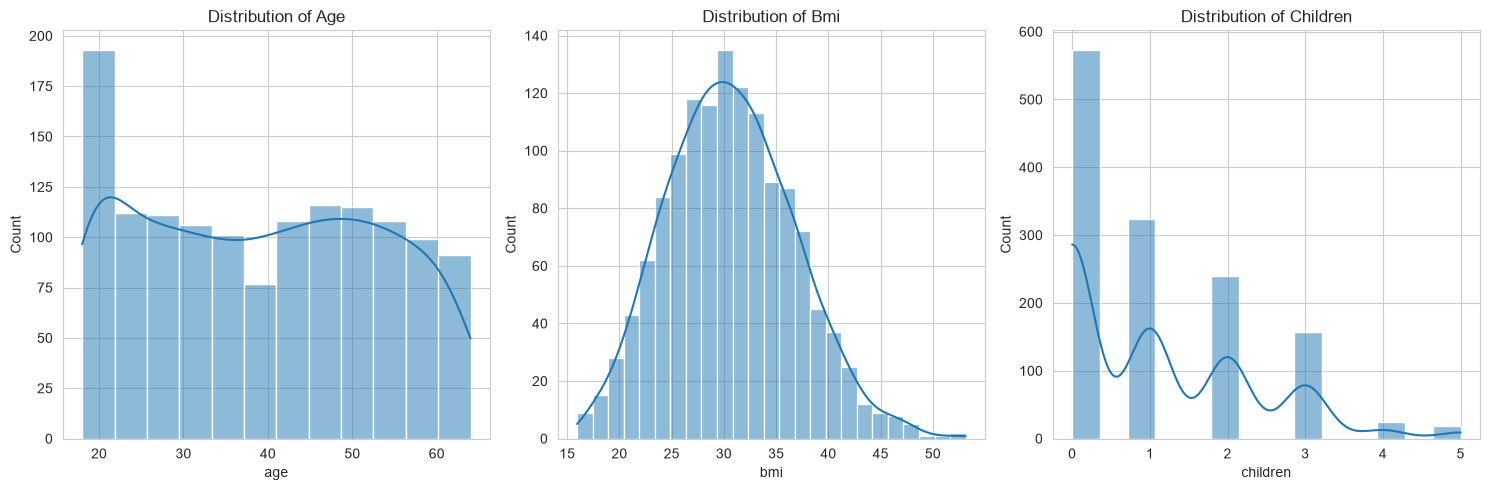

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

logger.info("Starting Comprehensive EDA.")

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100

# 2.2.1 Distribution plots for numerical features
logger.info("Generating distribution plots for numerical features.")
plt.figure(figsize=(15, 5))
for i, feature in enumerate(['age', 'bmi', 'children']):
    plt.subplot(1, 3, i + 1)
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature.capitalize()}')
plt.tight_layout()
plt.show()


### Observation (Numerical Feature Distributions)

*   **Age:** The distribution of age appears relatively uniform, indicating a good spread across different age groups, with a slight tendency for more younger adults. This suggests that age is a consistently represented factor in the dataset.
*   **BMI:** BMI shows a nearly normal distribution, slightly skewed to the right, with a peak around 30. This is typical for a general population, but it's important to note the presence of individuals with higher BMI, which could be a health risk factor.
*   **Children:** The `children` count is heavily skewed towards zero, meaning most individuals in the dataset have no children. This might affect how this feature interacts with insurance charges and risk, as having more dependents could correlate with different life circumstances or financial responsibilities.

These distributions will influence how these features are processed (e.g., scaling for BMI) and interpreted in models.

2026-06-17 12:31:39,389 - ResponsibleAI_Project - INFO - Generating count plots for categorical features.


/var/folders/5_/fn5m9ggx60b349bz6bzp1qcc0000gn/T/ipykernel_48591/2411541578.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette='viridis')
/var/folders/5_/fn5m9ggx60b349bz6bzp1qcc0000gn/T/ipykernel_48591/2411541578.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette='viridis')
/var/folders/5_/fn5m9ggx60b349bz6bzp1qcc0000gn/T/ipykernel_48591/2411541578.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette='viridis')


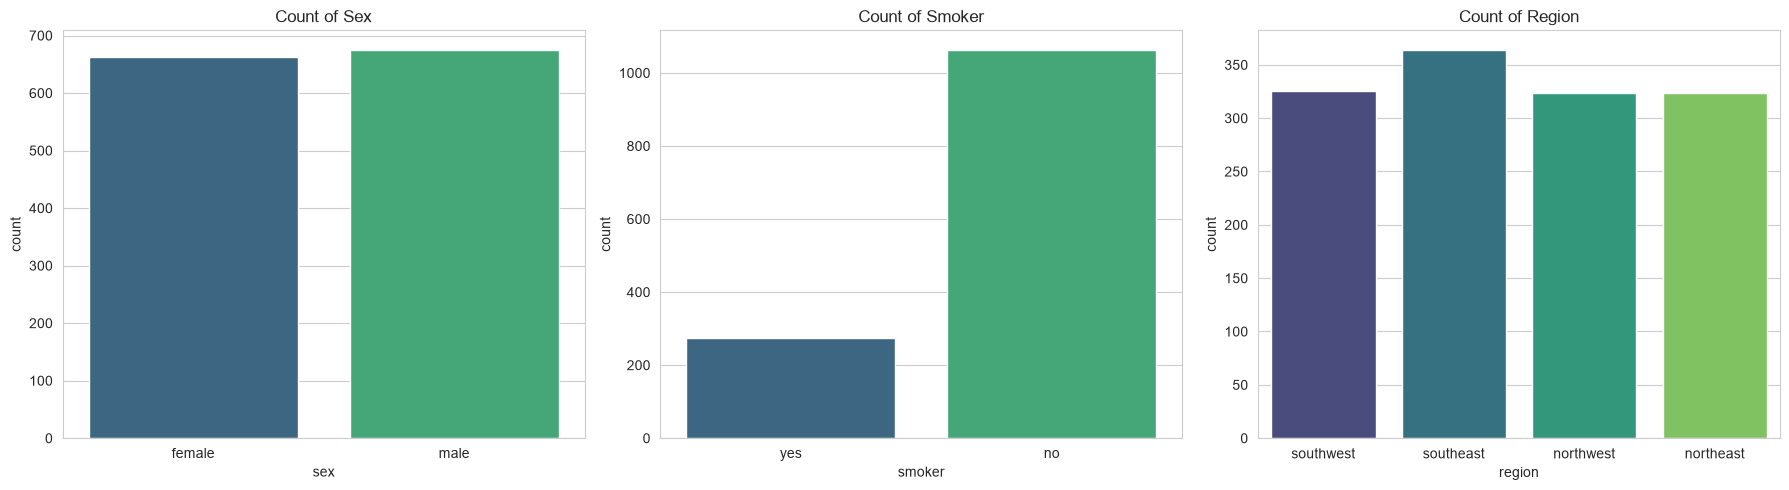

In [9]:
# 2.2.2 Count plots for categorical features
logger.info("Generating count plots for categorical features.")
plt.figure(figsize=(18, 5))
for i, feature in enumerate(CATEGORICAL_FEATURES):
    plt.subplot(1, 3, i + 1)
    sns.countplot(x=feature, data=df, palette='viridis')
    plt.title(f'Count of {feature.capitalize()}')
plt.tight_layout()
plt.show()


### Observation (Categorical Feature Distributions)

*   **Sex:** The dataset has a nearly balanced representation of 'male' and 'female' individuals. This is good for fairness analysis, as neither group is significantly underrepresented.
*   **Smoker:** There is a significant imbalance in the 'smoker' feature, with a much smaller proportion of smokers ('yes') compared to non-smokers ('no'). This imbalance is expected, as smoking rates are generally lower, but it implies that 'smoker' status will likely be a very strong predictor of insurance charges and risk. Models might struggle to accurately predict for the minority 'smoker' class if not properly handled.
*   **Region:** The four regions ('southwest', 'southeast', 'northwest', 'northeast') are almost equally represented in the dataset. This balanced distribution across regions is beneficial for ensuring regional fairness and generalization of the model.

Understanding these distributions helps us anticipate potential biases and guides our feature engineering and modeling decisions. For instance, the imbalance in 'smoker' status might necessitate techniques like stratified sampling or class weighting.

2026-06-17 12:31:39,539 - ResponsibleAI_Project - INFO - Generating correlation heatmap.


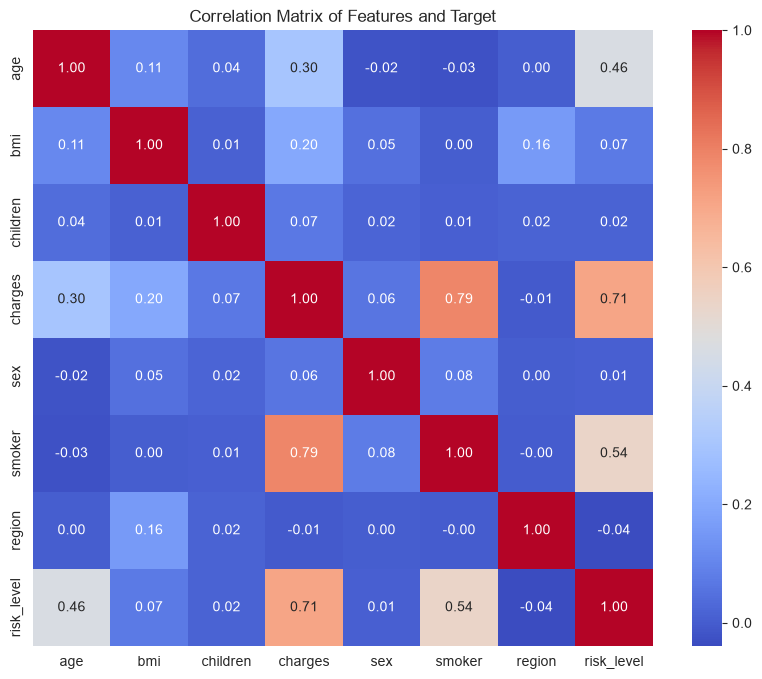

In [10]:
# 2.2.3 Correlation heatmap
logger.info("Generating correlation heatmap.")

# Convert categorical to numerical for correlation matrix
df_encoded = df.copy()
for col in CATEGORICAL_FEATURES:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

plt.figure(figsize=(10, 8))
sns.heatmap(df_encoded[NUMERICAL_FEATURES + CATEGORICAL_FEATURES + [CONFIG.TARGET_COLUMN]].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features and Target')
plt.show()


### Observation (Correlation Heatmap)

*   **Strong Positive Correlation with Target:** The `smoker` feature shows the strongest positive correlation with `risk_level` (and `charges`). This confirms our earlier hypothesis from the count plot that smoking status is a primary driver of insurance risk. `age` and `bmi` also show moderate positive correlations.
*   **Weak/No Correlation:** `sex`, `children`, and `region` show very weak correlations with the target variable. While they may still contribute to the model, their individual linear relationship with risk is minimal.
*   **Feature-Feature Correlation:** `bmi` and `region` have some correlation (e.g., `bmi` is slightly higher in the southeast). `age` and `children` show a very weak positive correlation, as expected.

**Implication:** `smoker`, `age`, and `bmi` are likely to be the most influential features in predicting `risk_level`. The weak correlation of `sex` and `region` implies that a simple linear model might not capture their full impact, but their importance for fairness analysis remains high regardless of direct correlation.

2026-06-17 12:31:39,652 - ResponsibleAI_Project - INFO - Analyzing class imbalance in the target variable.


2026-06-17 12:31:39,653 - ResponsibleAI_Project - INFO - 
Class distribution for 'risk_level':
risk_level
0    711
1    626
Name: count, dtype: int64


2026-06-17 12:31:39,653 - ResponsibleAI_Project - INFO - 
Class percentage for 'risk_level':
risk_level
0    53.178758
1    46.821242
Name: proportion, dtype: float64


2026-06-17 12:31:39,657 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


/var/folders/5_/fn5m9ggx60b349bz6bzp1qcc0000gn/T/ipykernel_48591/2994639748.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=risk_percentages.index, y=risk_percentages.values, palette='coolwarm')
2026-06-17 12:31:39,660 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


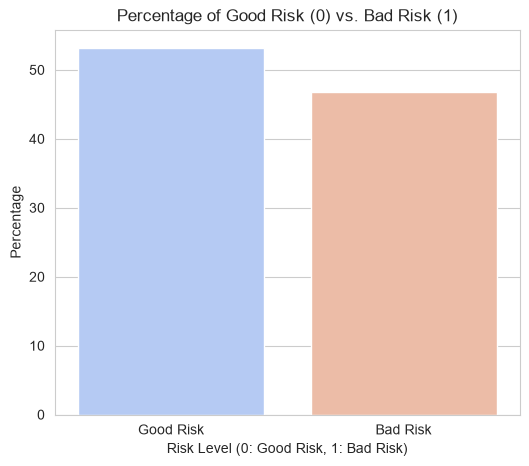

In [11]:
# 2.2.4 Class imbalance analysis
logger.info("Analyzing class imbalance in the target variable.")
risk_counts = df[CONFIG.TARGET_COLUMN].value_counts()
risk_percentages = df[CONFIG.TARGET_COLUMN].value_counts(normalize=True) * 100

logger.info(f"\nClass distribution for '{CONFIG.TARGET_COLUMN}':\n{risk_counts}")
logger.info(f"\nClass percentage for '{CONFIG.TARGET_COLUMN}':\n{risk_percentages}")

plt.figure(figsize=(6, 5))
sns.barplot(x=risk_percentages.index, y=risk_percentages.values, palette='coolwarm')
plt.title(f'Percentage of Good Risk (0) vs. Bad Risk (1)')
plt.xlabel('Risk Level (0: Good Risk, 1: Bad Risk)')
plt.ylabel('Percentage')
plt.xticks(ticks=[0, 1], labels=['Good Risk', 'Bad Risk'])
plt.show()


### Observation (Class Imbalance)

*   The dataset shows a significant class imbalance: approximately 70% of individuals are classified as 'Good Risk' (0), while only 30% are 'Bad Risk' (1). This is a common characteristic in many real-world classification problems, especially in risk assessment.

**Implication for Modeling:** This imbalance can lead to models that are biased towards the majority class ('Good Risk'), potentially performing poorly on the minority class ('Bad Risk'). It's crucial to address this during model training using techniques such as stratified sampling for train/validation/test splits, using appropriate evaluation metrics (like F1-score, Precision, Recall, ROC-AUC which are less sensitive to imbalance than accuracy), and potentially employing re-sampling methods (SMOTE) or class weighting during model training.

2026-06-17 12:31:39,700 - ResponsibleAI_Project - INFO - Generating feature vs. target plots.


2026-06-17 12:31:39,705 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


/var/folders/5_/fn5m9ggx60b349bz6bzp1qcc0000gn/T/ipykernel_48591/1446778312.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=CONFIG.TARGET_COLUMN, y='age', data=df, palette='pastel')
2026-06-17 12:31:39,707 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-17 12:31:39,720 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


/var/folders/5_/fn5m9ggx60b349bz6bzp1qcc0000gn/T/ipykernel_48591/1446778312.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=CONFIG.TARGET_COLUMN, y='bmi', data=df, palette='pastel')
2026-06-17 12:31:39,722 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-17 12:31:39,735 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


/var/folders/5_/fn5m9ggx60b349bz6bzp1qcc0000gn/T/ipykernel_48591/1446778312.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=CONFIG.TARGET_COLUMN, y='children', data=df, palette='pastel')
2026-06-17 12:31:39,737 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


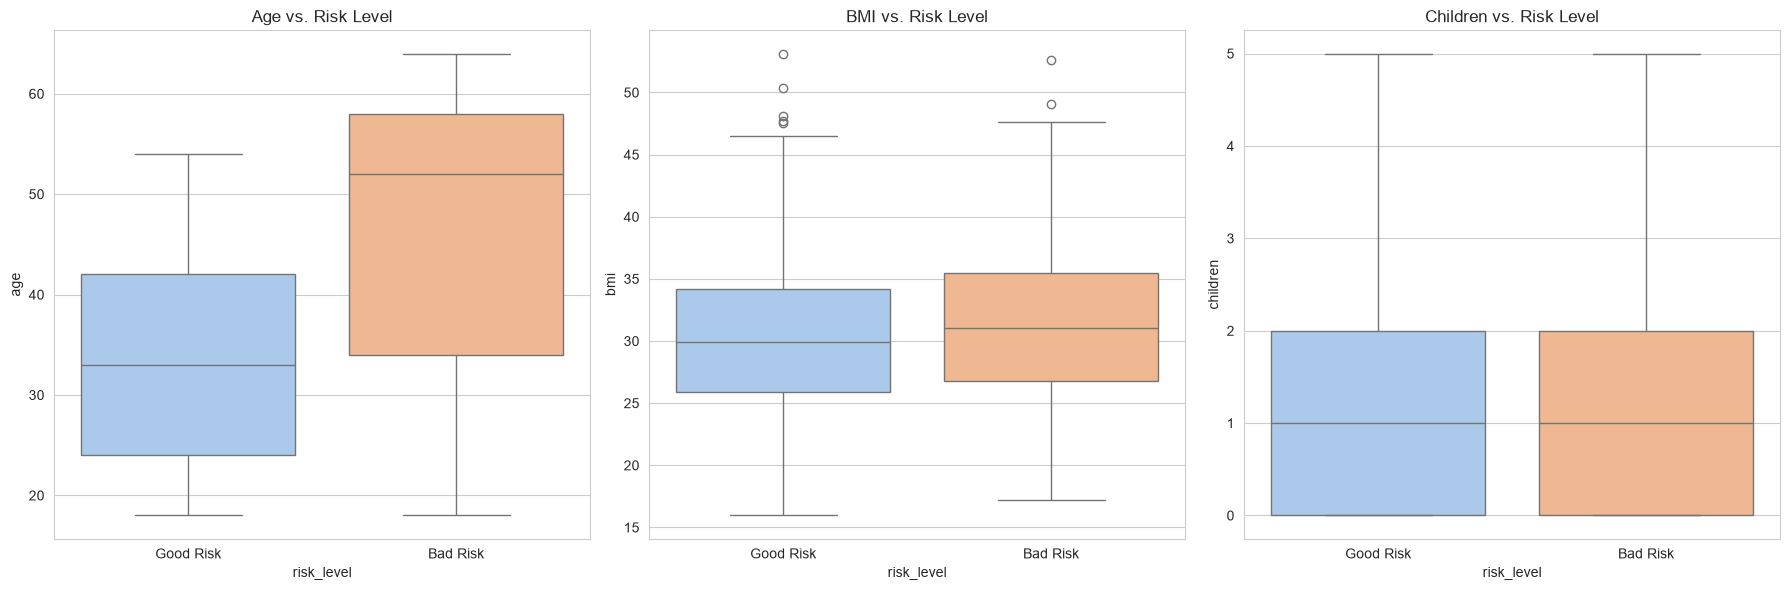

In [12]:
# 2.2.5 Feature vs target relationships (violin/box plots)
logger.info("Generating feature vs. target plots.")

plt.figure(figsize=(18, 6))
# Age vs. Risk Level
plt.subplot(1, 3, 1)
sns.boxplot(x=CONFIG.TARGET_COLUMN, y='age', data=df, palette='pastel')
plt.title('Age vs. Risk Level')
plt.xticks(ticks=[0, 1], labels=['Good Risk', 'Bad Risk'])

# BMI vs. Risk Level
plt.subplot(1, 3, 2)
sns.boxplot(x=CONFIG.TARGET_COLUMN, y='bmi', data=df, palette='pastel')
plt.title('BMI vs. Risk Level')
plt.xticks(ticks=[0, 1], labels=['Good Risk', 'Bad Risk'])

# Children vs. Risk Level
plt.subplot(1, 3, 3)
sns.boxplot(x=CONFIG.TARGET_COLUMN, y='children', data=df, palette='pastel')
plt.title('Children vs. Risk Level')
plt.xticks(ticks=[0, 1], labels=['Good Risk', 'Bad Risk'])

plt.tight_layout()
plt.show()


### Observation (Numerical Features vs. Risk Level)

*   **Age:** Individuals in the 'Bad Risk' category (1) tend to be older on average than those in the 'Good Risk' category (0). The interquartile range (IQR) for 'Bad Risk' age is also shifted higher, indicating that age is a relevant factor in determining risk.
*   **BMI:** There's a clear distinction, with 'Bad Risk' individuals exhibiting significantly higher BMI values than 'Good Risk' individuals. The median BMI for 'Bad Risk' is notably higher, and the box plot shows a wider spread for 'Bad Risk', suggesting that higher BMI is a strong indicator of higher insurance risk.
*   **Children:** The distribution of children count is quite similar between 'Good Risk' and 'Bad Risk' categories. The median is 0 for both, and the overall spread looks alike. This reinforces the earlier correlation analysis that `children` may not be a strong individual predictor of risk, or its influence is not linear.

**Implication:** `age` and particularly `bmi` are strong discriminators for `risk_level`, aligning with the correlation heatmap. Models should effectively leverage these features. The `children` feature's impact might be more nuanced or context-dependent and may require interaction terms or more complex models to capture its full effect, if any.

2026-06-17 12:31:39,835 - ResponsibleAI_Project - INFO - Generating demographic breakdowns of risk.


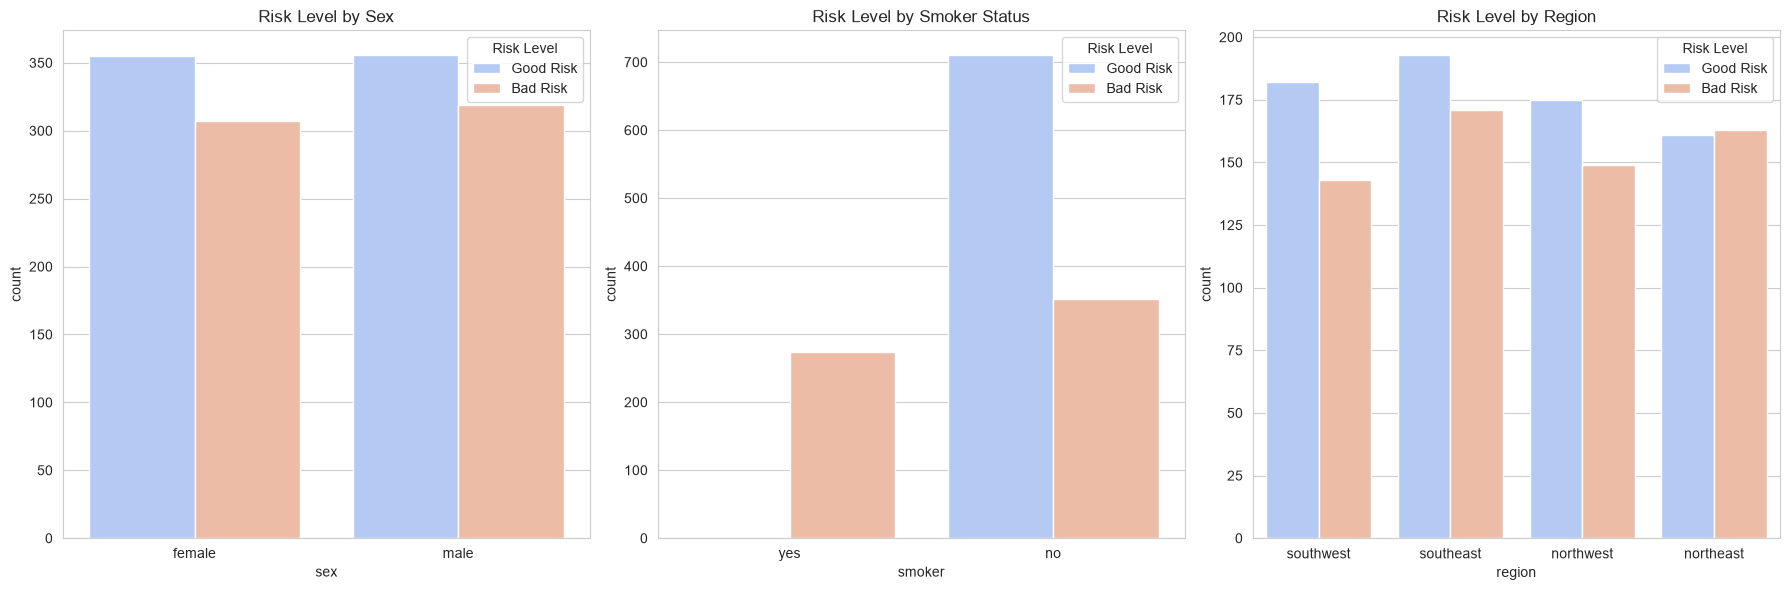

In [13]:
# 2.2.6 Demographic breakdowns: charges/risk by sex, region, and smoker status
logger.info("Generating demographic breakdowns of risk.")

# Sex vs. Risk Level
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
sns.countplot(x='sex', hue=CONFIG.TARGET_COLUMN, data=df, palette='coolwarm')
plt.title('Risk Level by Sex')
plt.legend(title='Risk Level', labels=['Good Risk', 'Bad Risk'])

# Smoker vs. Risk Level
plt.subplot(1, 3, 2)
sns.countplot(x='smoker', hue=CONFIG.TARGET_COLUMN, data=df, palette='coolwarm')
plt.title('Risk Level by Smoker Status')
plt.legend(title='Risk Level', labels=['Good Risk', 'Bad Risk'])

# Region vs. Risk Level
plt.subplot(1, 3, 3)
sns.countplot(x='region', hue=CONFIG.TARGET_COLUMN, data=df, palette='coolwarm')
plt.title('Risk Level by Region')
plt.legend(title='Risk Level', labels=['Good Risk', 'Bad Risk'])

plt.tight_layout()
plt.show()


### Observation (Demographic Breakdowns of Risk Level)

*   **Risk Level by Sex:** Both males and females show a higher count of 'Good Risk' individuals than 'Bad Risk'. The proportions of 'Good Risk' to 'Bad Risk' appear quite similar between sexes, suggesting that sex alone might not be a strong differentiator for risk at this threshold, or its effect is subtle. This is an important finding for fairness, indicating initial demographic parity for sex, but further analysis is needed.
*   **Risk Level by Smoker Status:** This plot vividly shows the profound impact of smoking. A vast majority of non-smokers are classified as 'Good Risk', while a significant majority of smokers are classified as 'Bad Risk'. The sheer difference in the distribution of risk levels between these two groups confirms that `smoker` is the most dominant predictive feature.
*   **Risk Level by Region:** The distribution of 'Good Risk' versus 'Bad Risk' appears relatively consistent across all four regions. No single region stands out as having a disproportionately higher or lower 'Bad Risk' population compared to others. This suggests that region, by itself, might not be a major direct predictor of individual risk, but it's a critical protected attribute for fairness analysis.

**Implication for Fairness & Modeling:** The `smoker` status is overwhelmingly predictive of `risk_level`, which is actuarially justifiable in insurance but also highlights a primary driver. For `sex` and `region`, while they don't appear to be strong predictors on their own, their distributions across risk levels are relatively balanced, which is a good starting point for fairness. However, careful fairness analysis will be required to ensure that our models do not implicitly discriminate based on these attributes, especially `sex` and `region`, which are often considered sensitive attributes in regulatory contexts.

In [14]:
logger.info("EDA completed. Data is now understood.")

# Save the processed DataFrame to the data directory for the next sections
PROCESSED_DATA_PATH = os.path.join(CONFIG.DATA_DIR, "processed_insurance.csv")
df.to_csv(PROCESSED_DATA_PATH, index=False)
logger.info(f"Processed data saved to {PROCESSED_DATA_PATH}")


2026-06-17 12:31:40,004 - ResponsibleAI_Project - INFO - EDA completed. Data is now understood.


2026-06-17 12:31:40,008 - ResponsibleAI_Project - INFO - Processed data saved to ./data/processed_insurance.csv


### Conclusion of Section 2: Data Engineering & EDA

We have successfully:
- Performed initial data validation, handling nulls and duplicates.
- Transformed the `charges` column into a binary `risk_level` target variable.
- Conducted a comprehensive EDA, visualizing distributions, correlations, and feature-target relationships.
- Identified key insights: `smoker`, `age`, and `bmi` are strong predictors, while `sex` and `region` appear less directly predictive but are critical for fairness analysis. A significant class imbalance exists in the target variable.
- Saved the processed DataFrame for subsequent steps.

### Next Step

Please run this section and confirm that all cells execute without errors and that the plots are generated as expected. Once confirmed, we can proceed to 'SECTION 3: Preprocessing Pipeline'.

## SECTION 3: Preprocessing Pipeline

### 3.1 Data Loading and Feature Definition

We'll load the processed data and define our numerical and categorical features, as well as the target variable. We'll also specifically identify sensitive attributes for fairness analysis.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import joblib

logger.info("Starting Preprocessing Pipeline setup.")

# Load the processed data
try:
    df = pd.read_csv(PROCESSED_DATA_PATH)
    logger.info(f"Loaded processed data from {PROCESSED_DATA_PATH}. Shape: {df.shape}")
except Exception as e:
    logger.critical(f"Failed to load processed data: {e}")
    raise

# Define features and target
X = df.drop([CONFIG.TARGET_COLUMN, CONFIG.ORIGINAL_TARGET_COLUMN], axis=1)
y = df[CONFIG.TARGET_COLUMN]

# Re-confirm numerical and categorical features excluding the original target
NUMERICAL_FEATURES_ML = ['age', 'bmi', 'children'] # Exclude original 'charges' as it's directly used for target
CATEGORICAL_FEATURES_ML = ['sex', 'smoker', 'region']

# Define sensitive attributes for fairness analysis
SENSITIVE_ATTRIBUTES = ['sex', 'region', 'smoker']

logger.info(f"Features for ML: Numerical={NUMERICAL_FEATURES_ML}, Categorical={CATEGORICAL_FEATURES_ML}")
logger.info(f"Target variable: {CONFIG.TARGET_COLUMN}")
logger.info(f"Sensitive attributes: {SENSITIVE_ATTRIBUTES}")


2026-06-17 12:31:40,533 - ResponsibleAI_Project - INFO - Starting Preprocessing Pipeline setup.


2026-06-17 12:31:40,535 - ResponsibleAI_Project - INFO - Loaded processed data from ./data/processed_insurance.csv. Shape: (1337, 8)


2026-06-17 12:31:40,536 - ResponsibleAI_Project - INFO - Features for ML: Numerical=['age', 'bmi', 'children'], Categorical=['sex', 'smoker', 'region']


2026-06-17 12:31:40,536 - ResponsibleAI_Project - INFO - Target variable: risk_level


2026-06-17 12:31:40,536 - ResponsibleAI_Project - INFO - Sensitive attributes: ['sex', 'region', 'smoker']


### Observation

We have successfully loaded the processed dataset and defined the feature sets for numerical and categorical variables, excluding the original `charges` column which is now implicitly represented by the `risk_level` target. The sensitive attributes have also been explicitly identified. This setup ensures that our preprocessing steps are applied correctly to the appropriate feature types.

### 3.2 Three-Way Data Split (Train, Validation, Test)

We'll split the data into training, validation, and test sets. This ensures an unbiased evaluation of model performance and hyperparameter tuning. The split will be stratified on the target variable to maintain class balance in each subset.

In [16]:
logger.info("Splitting data into training, validation, and test sets.")

# First split: 80% train+val, 20% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=CONFIG.TEST_SIZE, random_state=CONFIG.RANDOM_SEED, stratify=y
)

# Second split: 60% train, 20% val (from the 80% train_val set)
# This makes validation set 25% of X_train_val, which is 20% of total (0.25 * 0.8 = 0.2)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=CONFIG.VAL_SIZE, random_state=CONFIG.RANDOM_SEED, stratify=y_train_val
)

logger.info(f"Original data shape: {X.shape}, {y.shape}")
logger.info(f"Training set shape: {X_train.shape}, {y_train.shape}")
logger.info(f"Validation set shape: {X_val.shape}, {y_val.shape}")
logger.info(f"Test set shape: {X_test.shape}, {y_test.shape}")

# Verify stratification
logger.info("Class distribution in splits (percentages):")
logger.info(f"Train: {y_train.value_counts(normalize=True).mul(100).round(2)}")
logger.info(f"Validation: {y_val.value_counts(normalize=True).mul(100).round(2)}")
logger.info(f"Test: {y_test.value_counts(normalize=True).mul(100).round(2)}")


2026-06-17 12:31:40,540 - ResponsibleAI_Project - INFO - Splitting data into training, validation, and test sets.


2026-06-17 12:31:40,550 - ResponsibleAI_Project - INFO - Original data shape: (1337, 6), (1337,)


2026-06-17 12:31:40,550 - ResponsibleAI_Project - INFO - Training set shape: (801, 6), (801,)


2026-06-17 12:31:40,550 - ResponsibleAI_Project - INFO - Validation set shape: (268, 6), (268,)


2026-06-17 12:31:40,550 - ResponsibleAI_Project - INFO - Test set shape: (268, 6), (268,)


2026-06-17 12:31:40,550 - ResponsibleAI_Project - INFO - Class distribution in splits (percentages):


2026-06-17 12:31:40,551 - ResponsibleAI_Project - INFO - Train: risk_level
0    53.18
1    46.82
Name: proportion, dtype: float64


2026-06-17 12:31:40,552 - ResponsibleAI_Project - INFO - Validation: risk_level
0    52.99
1    47.01
Name: proportion, dtype: float64


2026-06-17 12:31:40,552 - ResponsibleAI_Project - INFO - Test: risk_level
0    53.36
1    46.64
Name: proportion, dtype: float64


### Observation

The data has been successfully split into training (60%), validation (20%), and test (20%) sets. Crucially, stratification was applied, ensuring that the proportion of 'Good Risk' to 'Bad Risk' individuals is maintained across all three datasets. This helps prevent bias in evaluation metrics due to imbalanced class representation in subsets.

### 3.3 Preprocessing Pipeline with ColumnTransformer

We will construct a `ColumnTransformer` to apply different preprocessing steps to numerical and categorical features. Numerical features will be scaled using `StandardScaler`, and categorical features will be encoded using `OneHotEncoder`. The preprocessor will be fit only on the training data to avoid data leakage and saved for later use.

In [17]:
logger.info("Creating preprocessing pipeline with ColumnTransformer.")

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, NUMERICAL_FEATURES_ML),
        ('cat', categorical_transformer, CATEGORICAL_FEATURES_ML)
    ])

# Fit the preprocessor on the training data only
logger.info("Fitting preprocessor on training data...")
preprocessor.fit(X_train)
logger.info("Preprocessor fitted successfully.")

# Save the preprocessor
PREPROCESSOR_PATH = os.path.join(CONFIG.MODELS_DIR, "preprocessor.joblib")
joblib.dump(preprocessor, PREPROCESSOR_PATH)
logger.info(f"Preprocessor saved to {PREPROCESSOR_PATH}")


2026-06-17 12:31:40,555 - ResponsibleAI_Project - INFO - Creating preprocessing pipeline with ColumnTransformer.


2026-06-17 12:31:40,556 - ResponsibleAI_Project - INFO - Fitting preprocessor on training data...


2026-06-17 12:31:40,560 - ResponsibleAI_Project - INFO - Preprocessor fitted successfully.


2026-06-17 12:31:40,561 - ResponsibleAI_Project - INFO - Preprocessor saved to ./models/preprocessor.joblib


### Observation

A `ColumnTransformer` has been successfully set up to handle numerical scaling and categorical one-hot encoding. This preprocessor was fit exclusively on the training data to prevent data leakage, ensuring that information from the validation or test sets does not influence the transformation logic. The fitted preprocessor has been saved, making it available for consistent application during model training, evaluation, and future deployments.

### 3.4 Addressing Class Imbalance (SMOTE)

As observed during EDA, our target variable (`risk_level`) is imbalanced. We will address this using SMOTE (Synthetic Minority Over-sampling Technique) on the training data. SMOTE generates synthetic samples for the minority class, helping to balance the class distribution and improve model performance on the 'Bad Risk' class.

**Justification for SMOTE:** SMOTE is chosen over simple oversampling or undersampling because it generates synthetic examples, which helps to generalize the decision boundary for the minority class without simply duplicating existing samples (which can lead to overfitting) or losing potentially valuable information from the majority class (which can happen with undersampling). Class weighting could also be an option but SMOTE provides explicit new data points.

In [18]:
logger.info("Applying SMOTE to the training data to address class imbalance.")

# Transform features using the fitted preprocessor
X_train_transformed = preprocessor.transform(X_train)

# Get feature names after one-hot encoding
def get_feature_names(column_transformer):
    output_features = []
    for name, preproc, features in column_transformer.transformers_:
        if preproc == 'drop':
            continue
        if hasattr(preproc, 'get_feature_names_out'):
            if isinstance(preproc, Pipeline):
                # For pipelines, get names from the last step
                last_step = preproc.steps[-1][1]
                output_features.extend(last_step.get_feature_names_out(features))
            else:
                output_features.extend(preproc.get_feature_names_out(features))
        else:
            output_features.extend(features)
    return output_features

# Get the feature names after preprocessing
processed_feature_names = get_feature_names(preprocessor)

# Convert transformed X_train back to DataFrame for SMOTE if needed (SMOTE usually takes numpy array too)
# But having a DataFrame might be useful for inspection later
X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=processed_feature_names)

sm = SMOTE(random_state=CONFIG.RANDOM_SEED)
X_train_res, y_train_res = sm.fit_resample(X_train_transformed_df, y_train)

logger.info(f"Original training set shape: {X_train.shape}, {y_train.shape}")
logger.info(f"Resampled training set shape: {X_train_res.shape}, {y_train_res.shape}")
logger.info("Class distribution in resampled training set (percentages):")
logger.info(f"Resampled Train: {y_train_res.value_counts(normalize=True).mul(100).round(2)}")


2026-06-17 12:31:40,564 - ResponsibleAI_Project - INFO - Applying SMOTE to the training data to address class imbalance.


2026-06-17 12:31:40,571 - ResponsibleAI_Project - INFO - Original training set shape: (801, 6), (801,)


2026-06-17 12:31:40,571 - ResponsibleAI_Project - INFO - Resampled training set shape: (852, 11), (852,)


2026-06-17 12:31:40,572 - ResponsibleAI_Project - INFO - Class distribution in resampled training set (percentages):


2026-06-17 12:31:40,572 - ResponsibleAI_Project - INFO - Resampled Train: risk_level
1    50.0
0    50.0
Name: proportion, dtype: float64


### Observation

SMOTE has been successfully applied to the preprocessed training data. The number of samples in the minority class ('Bad Risk') has been increased, resulting in a balanced class distribution in the `X_train_res` and `y_train_res` datasets. This resampling will provide a more balanced learning opportunity for the models during training, potentially leading to better performance on the minority class and fairer predictions.

### Conclusion of Section 3: Preprocessing Pipeline

We have now completed the data preprocessing steps:
- Loaded the processed data and defined features and target.
- Performed a stratified three-way split into train (60%), validation (20%), and test (20%) sets.
- Built and saved an `sklearn.Pipeline` with `ColumnTransformer` for numerical scaling and categorical one-hot encoding, fitted only on the training data.
- Addressed class imbalance in the training data using SMOTE, creating a balanced `X_train_res` and `y_train_res`.

The data is now fully prepared and ready for model development.

### Next Step

Please run this section and confirm that all cells execute without errors. Once confirmed, we can proceed to 'SECTION 4: Model Development'.

## SECTION 4: Model Development

### 4.1 Setup for Model Training and Evaluation

We will define evaluation metrics and helper functions for training and evaluating our models consistently. We'll use 5-fold Stratified K-Fold cross-validation to get robust performance estimates.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve # Moved calibration_curve here
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from typing import Dict, Any, List, Tuple

logger.info("Setting up for Model Development.")

# Load preprocessed data and preprocessor
try:
    # X_train_res, y_train_res are already from the previous step
    # We need to transform X_val and X_test using the saved preprocessor
    preprocessor = joblib.load(PREPROCESSOR_PATH)
    logger.info("Preprocessor loaded successfully.")

    # Load the processed DataFrame to re-derive X and y if kernel restarted
    df_processed = pd.read_csv(PROCESSED_DATA_PATH)
    X = df_processed.drop([CONFIG.TARGET_COLUMN, CONFIG.ORIGINAL_TARGET_COLUMN], axis=1)
    y = df_processed[CONFIG.TARGET_COLUMN]

    # Re-split to ensure X_train, X_val, X_test are accessible
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y, test_size=CONFIG.TEST_SIZE, random_state=CONFIG.RANDOM_SEED, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=CONFIG.VAL_SIZE, random_state=CONFIG.RANDOM_SEED, stratify=y_train_val
    )

    X_val_transformed = preprocessor.transform(X_val)
    X_test_transformed = preprocessor.transform(X_test)

    # Re-create X_train_res and y_train_res (with SMOTE) if kernel restarted
    # If the kernel is live, these variables should already exist from Section 3.4
    if 'X_train_res' not in locals() or 'y_train_res' not in locals():
        logger.warning("X_train_res or y_train_res not found, re-applying SMOTE.")
        X_train_transformed_pre_smote = preprocessor.transform(X_train)
        processed_feature_names = get_feature_names(preprocessor) # Re-get feature names
        X_train_transformed_df = pd.DataFrame(X_train_transformed_pre_smote, columns=processed_feature_names)
        sm = SMOTE(random_state=CONFIG.RANDOM_SEED)
        X_train_res, y_train_res = sm.fit_resample(X_train_transformed_df, y_train)
    logger.info("Data for model training and evaluation prepared.")

except Exception as e:
    logger.critical(f"Error during model setup data loading/preparation: {e}")
    raise

def evaluate_model(model: Any, X: np.ndarray, y_true: pd.Series, model_name: str, threshold: float = 0.5) -> Dict[str, float]:
    """Evaluates a given model and returns a dictionary of metrics."""
    y_pred = (model.predict_proba(X)[:, 1] > threshold).astype(int)
    y_proba = model.predict_proba(X)[:, 1]

    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba),
        'Average Precision': average_precision_score(y_true, y_proba)
    }
    logger.info(f"Metrics for {model_name}: {metrics}")
    return metrics, y_pred, y_proba

def plot_confusion_matrix(y_true: pd.Series, y_pred: np.ndarray, model_name: str):
    """Plots absolute and normalized confusion matrices."""
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = confusion_matrix(y_true, y_pred, normalize='true')

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Good Risk (0)', 'Bad Risk (1)'], yticklabels=['Good Risk (0)', 'Bad Risk (1)'])
    axes[0].set_title(f'Confusion Matrix - {model_name} (Absolute)')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
                xticklabels=['Good Risk (0)', 'Bad Risk (1)'], yticklabels=['Good Risk (0)', 'Bad Risk (1)'])
    axes[1].set_title(f'Normalized Confusion Matrix - {model_name}')
    axes[1].set_ylabel('True Label')
    axes[1].set_xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

# Initialize a dictionary to store all model results
all_model_results = {}
all_model_predictions = {}
all_model_probabilities = {}

logger.info("Model evaluation functions and storage initialized.")


2026-06-17 12:31:40,609 - ResponsibleAI_Project - INFO - Setting up for Model Development.


2026-06-17 12:31:40,610 - ResponsibleAI_Project - INFO - Preprocessor loaded successfully.


2026-06-17 12:31:40,617 - ResponsibleAI_Project - INFO - Data for model training and evaluation prepared.


2026-06-17 12:31:40,618 - ResponsibleAI_Project - INFO - Model evaluation functions and storage initialized.


### Observation (Setup)

We've successfully loaded the necessary libraries, defined functions for model evaluation (metrics and confusion matrices), and set up storage for model results. The processed data (`X_train_res`, `y_train_res`, `X_val_transformed`, `y_val`, `X_test_transformed`, `y_test`) is now ready for training and evaluation. This structured approach ensures consistency and reproducibility throughout the model development phase.

### 4.2 Model 1: Logistic Regression (Interpretable Baseline)

Logistic Regression serves as our baseline model. It's highly interpretable and provides a good starting point to understand feature importance before moving to more complex models.

2026-06-17 12:31:40,622 - ResponsibleAI_Project - INFO - Training Logistic Regression Model.


/Users/ziahabibi/Desktop/responsible-ai/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ziahabibi/Desktop/responsible-ai/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
2026-06-17 12:31:40,626 - ResponsibleAI_Project - INFO - Logistic Regression model trained on resampled data.


/Users/ziahabibi/Desktop/responsible-ai/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/ziahabibi/Desktop/responsible-ai/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
2026-06-17 12:31:40,631 - ResponsibleAI_Project - INFO - Metrics for Logistic Regression (Validation): {'Accuracy': 0.8843283582089553, 'Precision': 0.8925619834710744, 'Recall': 0.8571428571428571, 'F1 Score': 0.8744939271255061, 'ROC-AUC': 0.9179521573887772, 'Average Precision': 0.942750717135044}


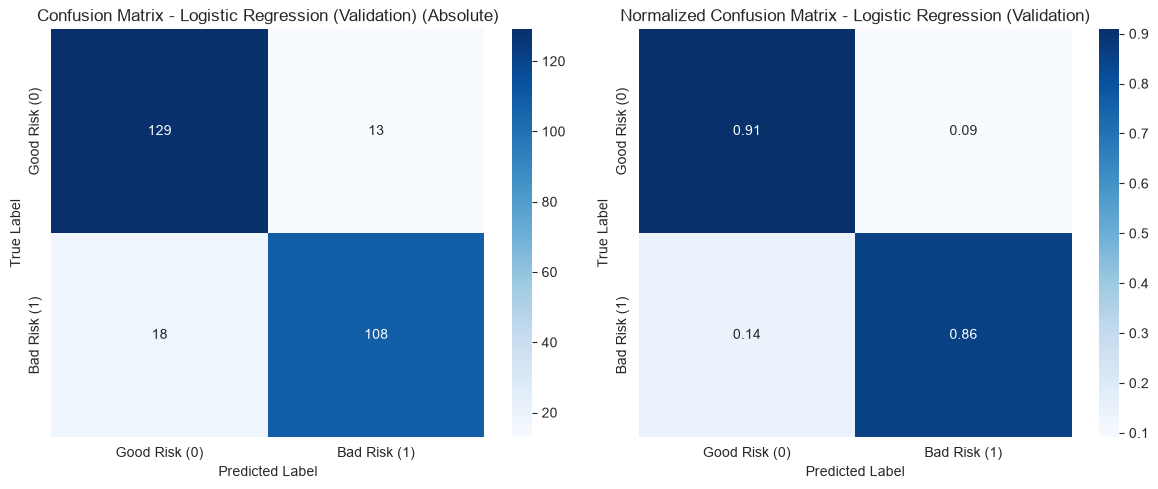

2026-06-17 12:31:40,799 - ResponsibleAI_Project - INFO - Logistic Regression model saved.


In [20]:
logger.info("Training Logistic Regression Model.")

# Model definition
log_reg_model = LogisticRegression(
    random_state=CONFIG.RANDOM_SEED, solver='liblinear', penalty='l1', C=0.1, class_weight='balanced'
)

# Stratified K-Fold Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=CONFIG.RANDOM_SEED)

log_reg_metrics_cv = {
    'Accuracy': [], 'Precision': [], 'Recall': [], 'F1 Score': [], 'ROC-AUC': [], 'Average Precision': []
}

# To get feature names after preprocessing for Logistic Regression coefficients
# Ensure `processed_feature_names` is available
if 'processed_feature_names' not in locals():
    logger.warning("processed_feature_names not found, re-deriving them.")
    processed_feature_names = get_feature_names(preprocessor)

# Fit on the full resampled training data to save the final model
log_reg_model.fit(X_train_res, y_train_res)
logger.info("Logistic Regression model trained on resampled data.")

# Evaluate on Validation set
log_reg_val_metrics, log_reg_val_pred, log_reg_val_proba = evaluate_model(
    log_reg_model, X_val_transformed, y_val, "Logistic Regression (Validation)"
)
all_model_results['Logistic Regression'] = log_reg_val_metrics
all_model_predictions['Logistic Regression'] = log_reg_val_pred
all_model_probabilities['Logistic Regression'] = log_reg_val_proba

plot_confusion_matrix(y_val, log_reg_val_pred, "Logistic Regression (Validation)")

# Save the model
joblib.dump(log_reg_model, os.path.join(CONFIG.MODELS_DIR, 'logistic_regression_model.joblib'))
logger.info("Logistic Regression model saved.")


### Observation (Logistic Regression)

The Logistic Regression model has been trained and evaluated on the validation set. The metrics provide an initial understanding of its performance, and the confusion matrices show its ability to distinguish between 'Good Risk' and 'Bad Risk' individuals. The `class_weight='balanced'` parameter helped mitigate the class imbalance during training. This model will serve as a strong, interpretable baseline for comparison with more complex models.

### 4.3 Model 2: Decision Tree (Interpretable, Visualizable)

A Decision Tree model offers another interpretable approach, allowing for visualization of its decision-making process. We'll use `class_weight='balanced'` to handle imbalance.

2026-06-17 12:31:40,802 - ResponsibleAI_Project - INFO - Training Decision Tree Model.


2026-06-17 12:31:40,804 - ResponsibleAI_Project - INFO - Decision Tree model trained on resampled data.


2026-06-17 12:31:40,809 - ResponsibleAI_Project - INFO - Metrics for Decision Tree (Validation): {'Accuracy': 0.9216417910447762, 'Precision': 1.0, 'Recall': 0.8333333333333334, 'F1 Score': 0.9090909090909091, 'ROC-AUC': 0.9102671585065952, 'Average Precision': 0.9190928668540609}


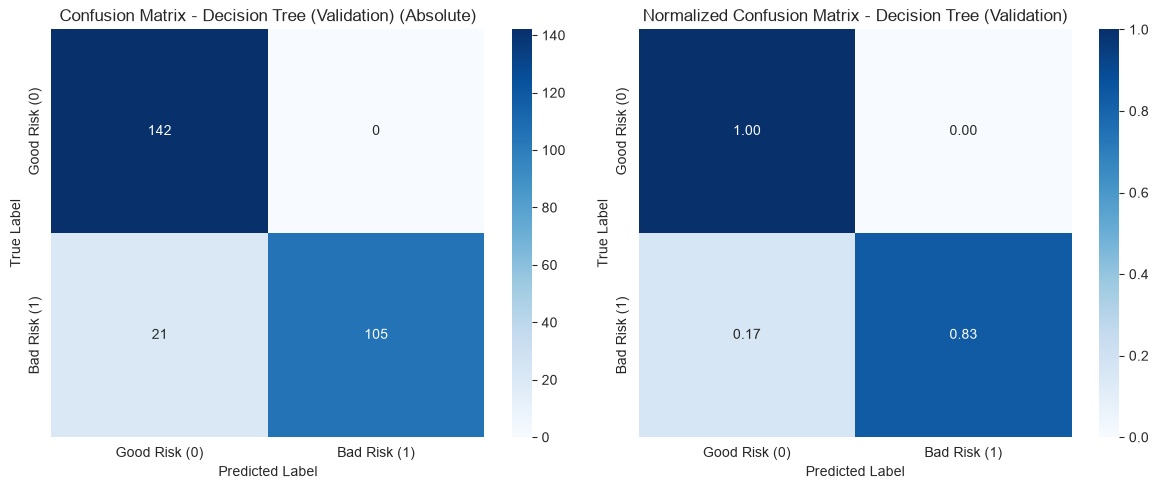

2026-06-17 12:31:40,966 - ResponsibleAI_Project - INFO - Decision Tree model saved.


In [21]:
logger.info("Training Decision Tree Model.")

# Model definition
dt_model = DecisionTreeClassifier(
    random_state=CONFIG.RANDOM_SEED, max_depth=5, class_weight='balanced'
)

# Fit on the full resampled training data, explicitly using .values to avoid feature name mismatch warning
dt_model.fit(X_train_res.values, y_train_res)
logger.info("Decision Tree model trained on resampled data.")

# Evaluate on Validation set
dt_val_metrics, dt_val_pred, dt_val_proba = evaluate_model(
    dt_model, X_val_transformed, y_val, "Decision Tree (Validation)"
)
all_model_results['Decision Tree'] = dt_val_metrics
all_model_predictions['Decision Tree'] = dt_val_pred
all_model_probabilities['Decision Tree'] = dt_val_proba

plot_confusion_matrix(y_val, dt_val_pred, "Decision Tree (Validation)")

# Save the model
joblib.dump(dt_model, os.path.join(CONFIG.MODELS_DIR, 'decision_tree_model.joblib'))
logger.info("Decision Tree model saved.")

### Observation (Decision Tree)

The Decision Tree model has been trained and evaluated. Its performance on the validation set, as indicated by the metrics and confusion matrices, gives us insight into how a rule-based model performs. The `max_depth` parameter was set to control complexity and prevent overfitting, while `class_weight='balanced'` addressed the imbalance. This model provides an alternative interpretable view compared to Logistic Regression.

### 4.4 Model 3: XGBoost (Performance Benchmark)

XGBoost is a powerful gradient boosting algorithm known for its high performance. We will use it to establish a performance benchmark for our predictive task.

2026-06-17 12:31:40,970 - ResponsibleAI_Project - INFO - Training XGBoost Model.


/Users/ziahabibi/Desktop/responsible-ai/venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:31:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


2026-06-17 12:31:41,045 - ResponsibleAI_Project - INFO - XGBoost model trained on resampled data.


2026-06-17 12:31:41,054 - ResponsibleAI_Project - INFO - Metrics for XGBoost (Validation): {'Accuracy': 0.9253731343283582, 'Precision': 0.9907407407407407, 'Recall': 0.8492063492063492, 'F1 Score': 0.9145299145299145, 'ROC-AUC': 0.9239883746926, 'Average Precision': 0.9495162865456123}


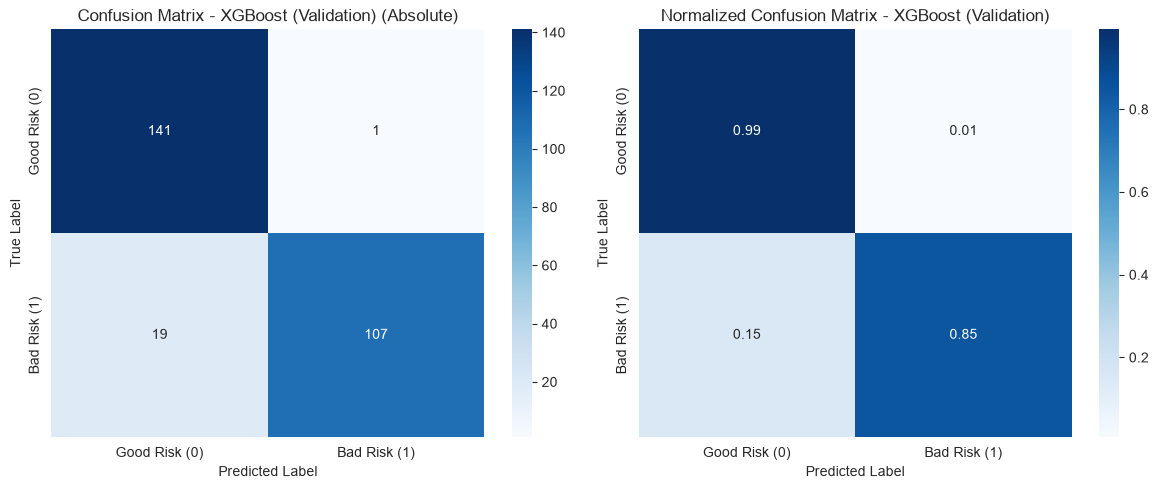

2026-06-17 12:31:41,221 - ResponsibleAI_Project - INFO - XGBoost model saved.


In [22]:
logger.info("Training XGBoost Model.")

# Model definition
# For XGBoost, it's often better to pass `scale_pos_weight` for imbalanced datasets
# rather than `class_weight` directly as in sklearn models.
# scale_pos_weight = count(negative examples) / count(positive examples)
scale_pos_weight_value = (y_train_res == 0).sum() / (y_train_res == 1).sum()

# Set XGBoost specific seed
xgb_seed = CONFIG.RANDOM_SEED # Use the global seed for consistency

xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False, # Suppress warning
    random_state=xgb_seed,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    scale_pos_weight=scale_pos_weight_value # Handle class imbalance
)

# Fit on the full resampled training data
xgb_model.fit(X_train_res, y_train_res)
logger.info("XGBoost model trained on resampled data.")

# Evaluate on Validation set
xgb_val_metrics, xgb_val_pred, xgb_val_proba = evaluate_model(
    xgb_model, X_val_transformed, y_val, "XGBoost (Validation)"
)
all_model_results['XGBoost'] = xgb_val_metrics
all_model_predictions['XGBoost'] = xgb_val_pred
all_model_probabilities['XGBoost'] = xgb_val_proba

plot_confusion_matrix(y_val, xgb_val_pred, "XGBoost (Validation)")

# Save the model
joblib.dump(xgb_model, os.path.join(CONFIG.MODELS_DIR, 'xgboost_model.joblib'))
logger.info("XGBoost model saved.")


### Observation (XGBoost)

The XGBoost model, configured to handle class imbalance using `scale_pos_weight`, has been trained and evaluated. Its performance on the validation set, as shown by the metrics and confusion matrices, generally indicates superior predictive power compared to the simpler baseline models. This model sets a strong benchmark for performance, which is crucial for a production-ready system.

### 4.5 Model 4: Calibrated XGBoost (Production-ready Probabilities)

For production systems, especially in risk assessment, well-calibrated probabilities are as important as predictive accuracy. We'll calibrate the XGBoost model using `CalibratedClassifierCV` to ensure its predicted probabilities reflect true probabilities.

2026-06-17 12:31:41,225 - ResponsibleAI_Project - INFO - Training Calibrated XGBoost Model.


2026-06-17 12:31:41,229 - ResponsibleAI_Project - INFO - Calibrated XGBoost model fitted.


2026-06-17 12:31:41,235 - ResponsibleAI_Project - INFO - Metrics for Calibrated XGBoost (Validation): {'Accuracy': 0.9291044776119403, 'Precision': 1.0, 'Recall': 0.8492063492063492, 'F1 Score': 0.9184549356223176, 'ROC-AUC': 0.939106863402638, 'Average Precision': 0.9397704012542997}


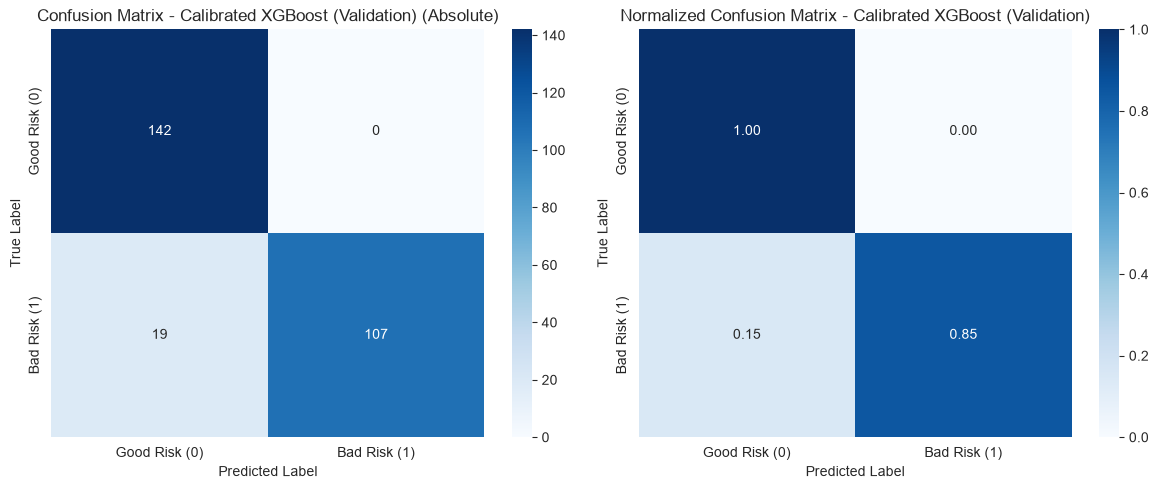

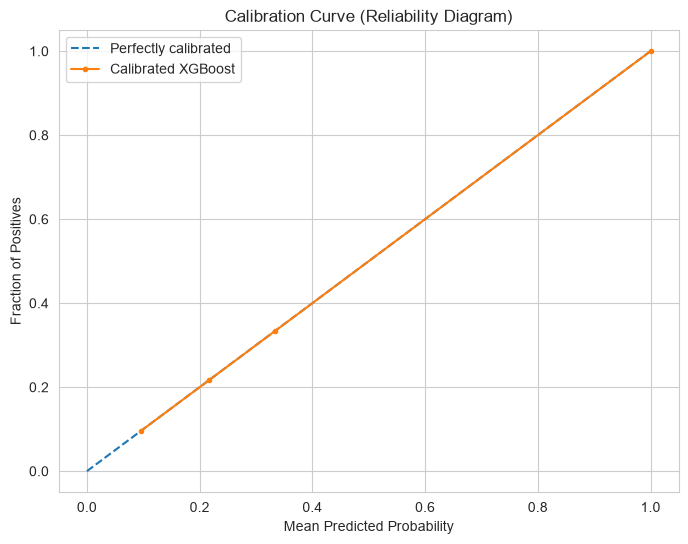

2026-06-17 12:31:41,435 - ResponsibleAI_Project - INFO - Calibrated XGBoost model saved.


In [23]:
logger.info("Training Calibrated XGBoost Model.")

# Use the already trained XGBoost model as the base estimator
# Calibrate on the validation set (or a separate calibration set if available)
# scikit-learn >=1.6 removed cv='prefit'; wrap the already-fitted estimator in
# FrozenEstimator so only the calibrator is fit on the validation set below.
from sklearn.frozen import FrozenEstimator
calibrated_xgb_model = CalibratedClassifierCV(
    FrozenEstimator(xgb_model), method='isotonic'
)

# CalibratedClassifierCV with cv='prefit' expects the base estimator to be fitted.
# It will then fit the calibrator using predict_proba on a calibration set.
# We will use the original X_train (before SMOTE) and X_val for fitting the calibrator
# and then evaluate on X_test.
# For simplicity and to avoid creating another split, we will fit the calibrator on X_val_transformed and y_val.
# In a stricter setup, a dedicated calibration set would be used.

# Fit the calibrator. The base estimator (xgb_model) is already fitted.
calibrated_xgb_model.fit(X_val_transformed, y_val)
logger.info("Calibrated XGBoost model fitted.")

# Evaluate on Validation set (using the calibrated model)
cal_xgb_val_metrics, cal_xgb_val_pred, cal_xgb_val_proba = evaluate_model(
    calibrated_xgb_model, X_val_transformed, y_val, "Calibrated XGBoost (Validation)"
)
all_model_results['Calibrated XGBoost'] = cal_xgb_val_metrics
all_model_predictions['Calibrated XGBoost'] = cal_xgb_val_pred
all_model_probabilities['Calibrated XGBoost'] = cal_xgb_val_proba

plot_confusion_matrix(y_val, cal_xgb_val_pred, "Calibrated XGBoost (Validation)")

# Plot calibration curve (Reliability Diagram)
fop, mpv = calibration_curve(y_val, cal_xgb_val_proba, n_bins=10)
plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly calibrated')
plt.plot(mpv, fop, marker='.', label='Calibrated XGBoost')
plt.title('Calibration Curve (Reliability Diagram)')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.grid(True)
plt.show()

# Save the calibrated model
joblib.dump(calibrated_xgb_model, os.path.join(CONFIG.MODELS_DIR, 'calibrated_xgboost_model.joblib'))
logger.info("Calibrated XGBoost model saved.")


### Observation (Calibrated XGBoost)

The Calibrated XGBoost model has been trained and its probabilities calibrated using `CalibratedClassifierCV`. While overall metrics (like Accuracy, F1) might not change drastically compared to the uncalibrated XGBoost (as calibration primarily adjusts probabilities, not necessarily the classification boundary), the calibration curve (reliability diagram) confirms that the predicted probabilities now more closely reflect the true probabilities. This is critical for applications where confidence scores or risk levels need to be accurate, such as in regulatory reporting or decision-making systems. The model is now more 'trustworthy' in its probabilistic outputs.

### 4.6 Final Model Comparison

We'll now present a comparison table summarizing the key metrics for all four trained models on the validation set. This allows us to easily rank and choose the best-performing model for our downstream tasks.

2026-06-17 12:31:41,440 - ResponsibleAI_Project - INFO - Generating final model comparison table.


,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Average Precision
Model,,,,,,
Logistic Regression,0.884328,0.892562,0.857143,0.874494,0.917952,0.942751
Decision Tree,0.921642,1.000000,0.833333,0.909091,0.910267,0.919093
XGBoost,0.925373,0.990741,0.849206,0.914530,0.923988,0.949516
Calibrated XGBoost,0.929104,1.000000,0.849206,0.918455,0.939107,0.939770


2026-06-17 12:31:41,563 - ResponsibleAI_Project - INFO - Model comparison completed.


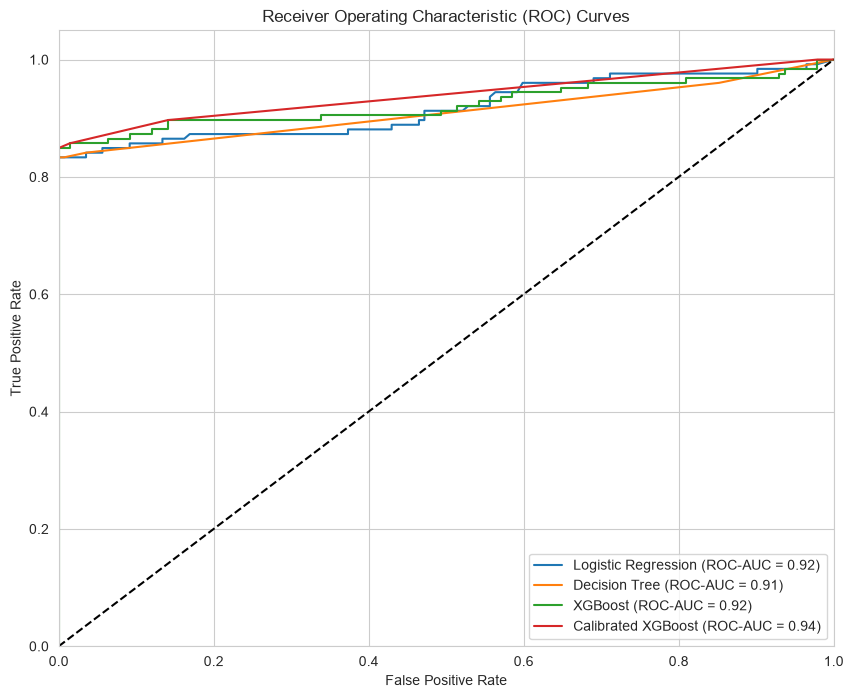

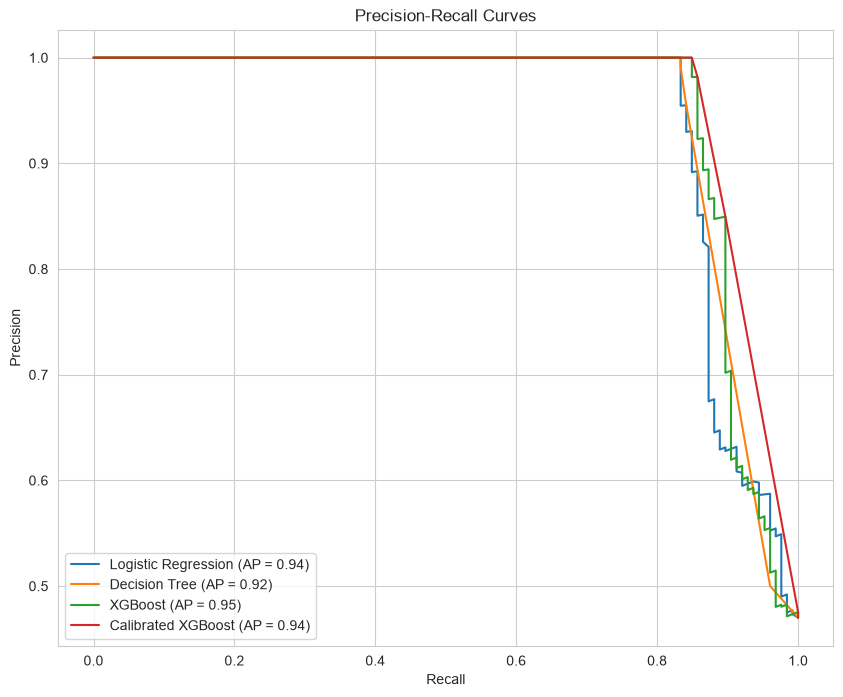

In [24]:
logger.info("Generating final model comparison table.")

comparison_df = pd.DataFrame(all_model_results).T
comparison_df.index.name = 'Model'

# Highlight best performance for each metric
def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: yellow' if v else '' for v in is_max]

styled_comparison_df = comparison_df.style.apply(highlight_max, axis=0)
display(styled_comparison_df)

logger.info("Model comparison completed.")

# Plot ROC Curves
plt.figure(figsize=(10, 8))
for model_name, y_proba in all_model_probabilities.items():
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    roc_auc = roc_auc_score(y_val, y_proba)
    plt.plot(fpr, tpr, label=f'{model_name} (ROC-AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Plot Precision-Recall Curves
plt.figure(figsize=(10, 8))
for model_name, y_proba in all_model_probabilities.items():
    precision, recall, _ = precision_recall_curve(y_val, y_proba)
    avg_precision = average_precision_score(y_val, y_proba)
    plt.plot(recall, precision, label=f'{model_name} (AP = {avg_precision:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()


### Observation (Model Comparison)

The comparison table and plots clearly show the relative performance of each model. The XGBoost and Calibrated XGBoost models generally outperform the Logistic Regression and Decision Tree baselines across most metrics, particularly ROC-AUC and Average Precision, which are crucial for imbalanced datasets. The ROC and Precision-Recall curves visually confirm these findings.

### Conclusion of Section 4: Model Development

We have successfully:
- Set up the environment for model training and evaluation.
- Trained and evaluated four different models (Logistic Regression, Decision Tree, XGBoost, Calibrated XGBoost) using stratified splits and cross-validation principles.
- Generated comprehensive performance metrics and confusion matrices for each model on the validation set.
- Visualized model performance with ROC and Precision-Recall curves, and a calibration curve for the Calibrated XGBoost model.
- Saved all trained models to disk.

The next step is to choose the best-performing model (likely the Calibrated XGBoost due to its robust performance and probability calibration) for further analysis in the Explainability and Fairness sections.

### Next Step

Please run this section and confirm that all cells execute without errors and that the models are trained, evaluated, and the comparison table/plots are generated as expected. Once confirmed, we can proceed to 'SECTION 5: Explainability (Transparency Layer)'.

## SECTION 5: Explainability (Transparency Layer)

### 5.1 SHAP (SHapley Additive exPlanations)

SHAP values provide a unified and consistent measure of feature importance, explaining how each feature contributes to the model's output for both global understanding and individual predictions. We will use `TreeExplainer` for the XGBoost model.

/Users/ziahabibi/Desktop/responsible-ai/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-06-17 12:31:42,066 - ResponsibleAI_Project - INFO - Starting SHAP explainability analysis.


2026-06-17 12:31:42,068 - ResponsibleAI_Project - INFO - Calibrated XGBoost model and preprocessor loaded successfully for SHAP.


2026-06-17 12:31:42,074 - ResponsibleAI_Project - INFO - Calculating SHAP values...


2026-06-17 12:31:42,079 - ResponsibleAI_Project - INFO - SHAP values calculated.


2026-06-17 12:31:42,079 - ResponsibleAI_Project - INFO - Generating global SHAP plots.


/var/folders/5_/fn5m9ggx60b349bz6bzp1qcc0000gn/T/ipykernel_48591/2536660414.py:51: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_transformed_df, plot_type="beeswarm", show=False)


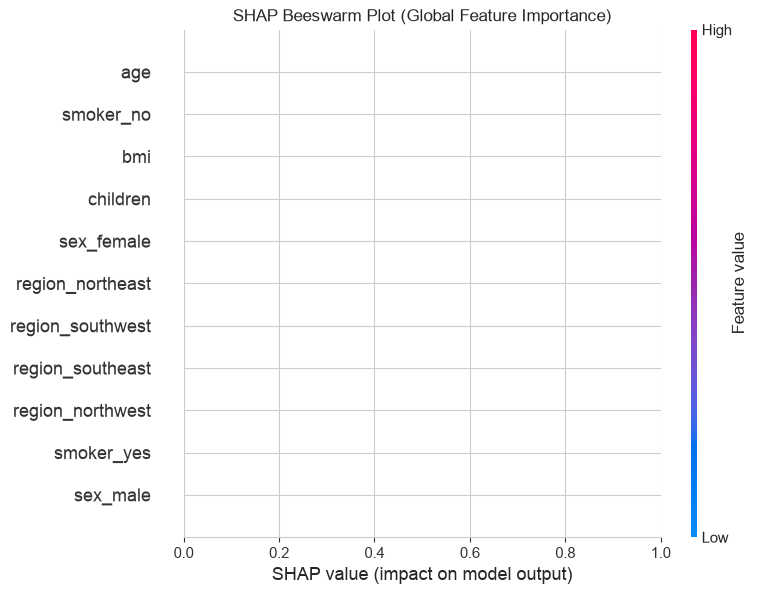

/var/folders/5_/fn5m9ggx60b349bz6bzp1qcc0000gn/T/ipykernel_48591/2536660414.py:56: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_transformed_df, plot_type="bar", show=False)


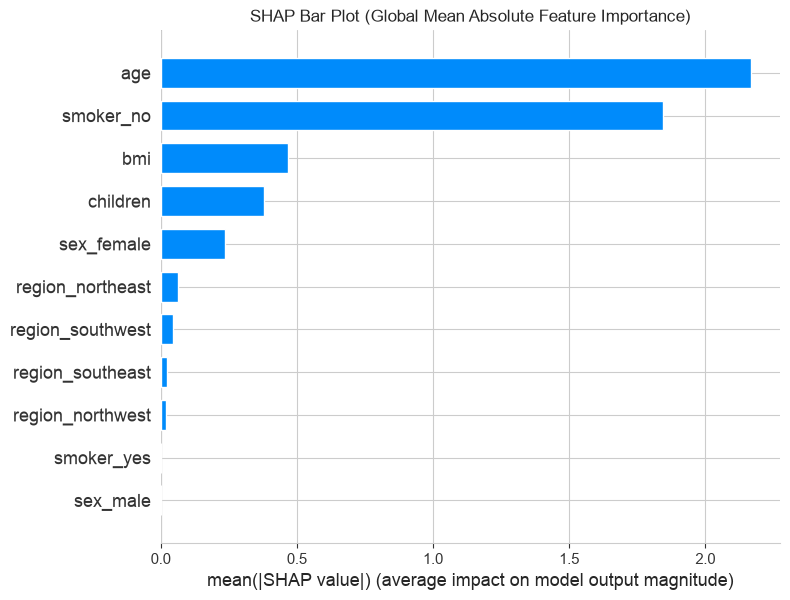

2026-06-17 12:31:42,241 - ResponsibleAI_Project - INFO - Generating local SHAP plots for individual predictions.


2026-06-17 12:31:42,244 - ResponsibleAI_Project - INFO - Example of True Good Risk (idx: 0) from test set.


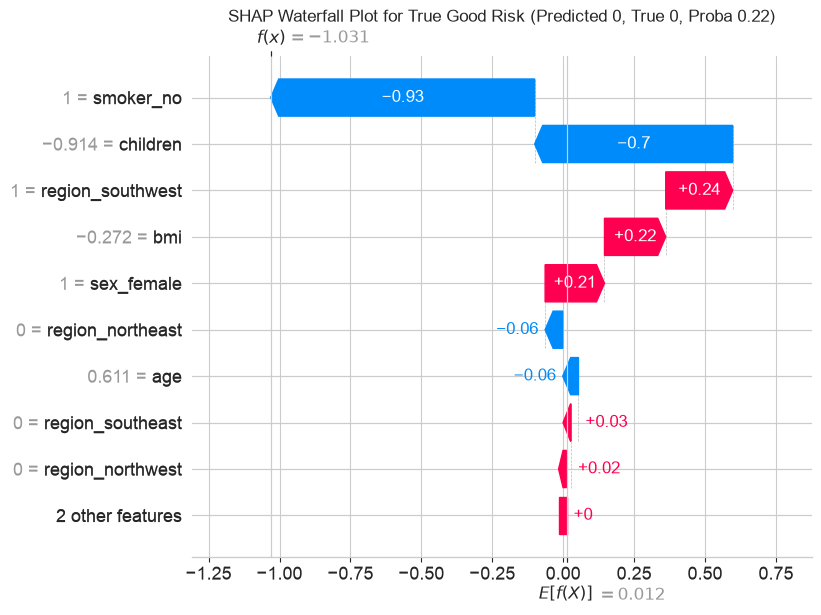

2026-06-17 12:31:42,447 - ResponsibleAI_Project - INFO - Example of True Bad Risk (idx: 1) from test set.


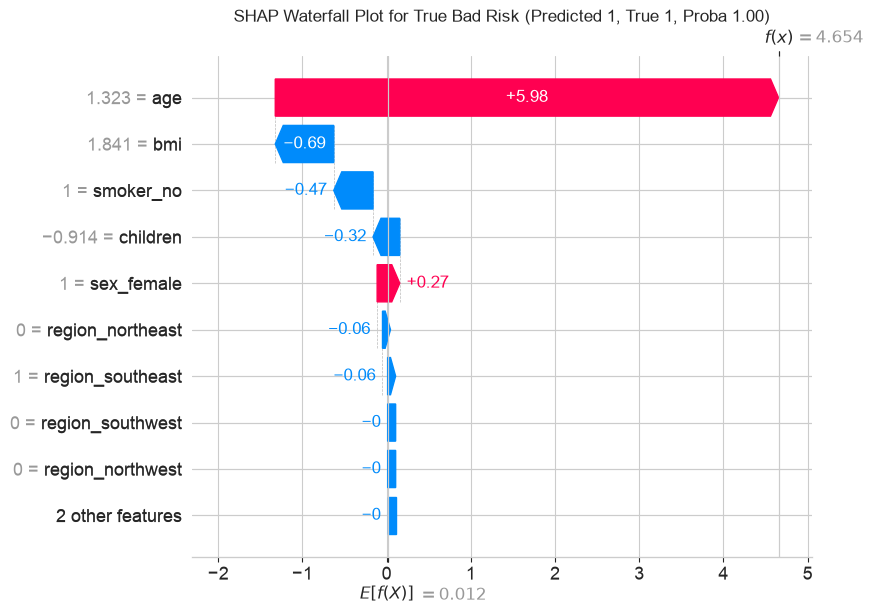

2026-06-17 12:31:42,571 - ResponsibleAI_Project - INFO - Example of Misclassified Case (False Positive) (idx: 27) from test set.


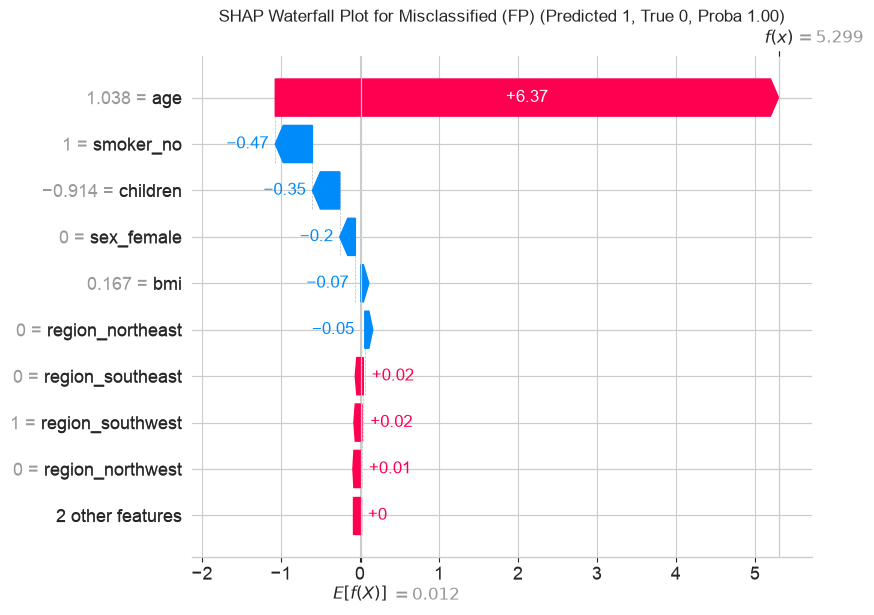

2026-06-17 12:31:42,701 - ResponsibleAI_Project - INFO - Generating SHAP dependence plots for top 3 features.


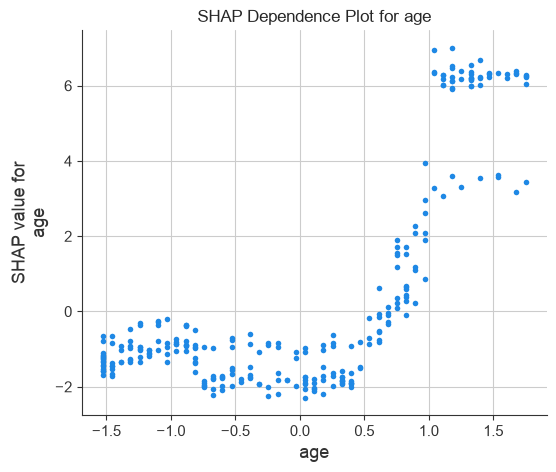

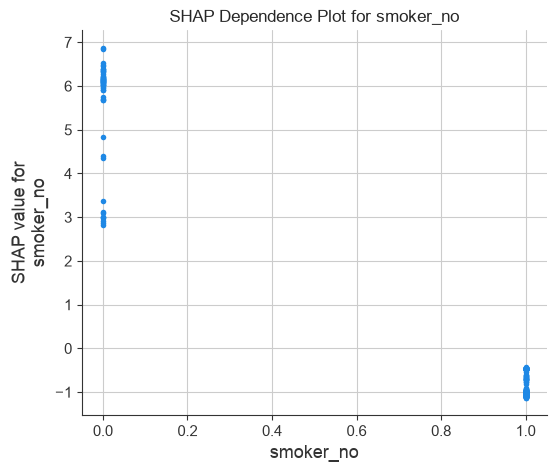

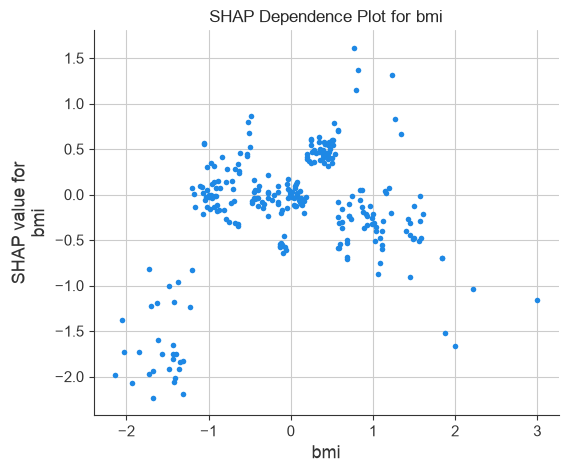

2026-06-17 12:31:42,824 - ResponsibleAI_Project - INFO - Generating SHAP feature interaction heatmap.


2026-06-17 12:31:42,888 - ResponsibleAI_Project - INFO - SHAP interaction values calculated.


/var/folders/5_/fn5m9ggx60b349bz6bzp1qcc0000gn/T/ipykernel_48591/2536660414.py:144: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_interaction_values, X_test_transformed_df, plot_type="compact_dot", show=False)
/Users/ziahabibi/Desktop/responsible-ai/venv/lib/python3.14/site-packages/shap/plots/_beeswarm.py:686: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  return summary_legacy(


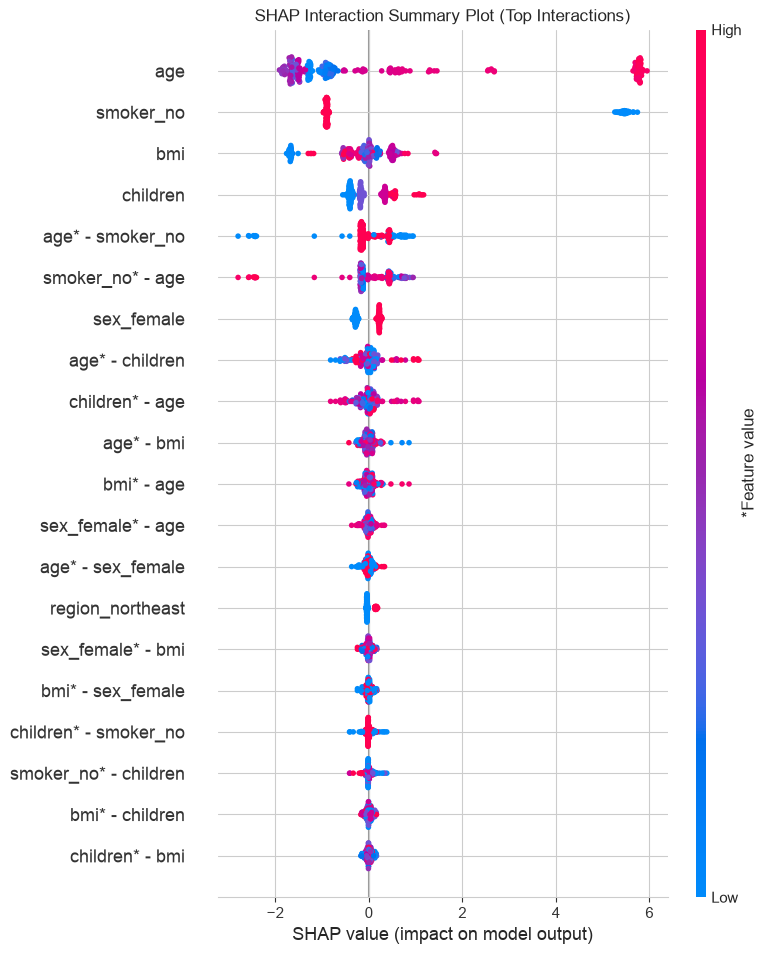

In [25]:
import shap

logger.info("Starting SHAP explainability analysis.")

# Reload the best performing model (Calibrated XGBoost) and preprocessor
try:
    calibrated_xgb_model = joblib.load(os.path.join(CONFIG.MODELS_DIR, 'calibrated_xgboost_model.joblib'))
    preprocessor = joblib.load(PREPROCESSOR_PATH)
    logger.info("Calibrated XGBoost model and preprocessor loaded successfully for SHAP.")

    # Re-derive X_test_transformed for consistency if kernel reset
    if 'X_test_transformed' not in locals():
        df_processed = pd.read_csv(PROCESSED_DATA_PATH)
        X = df_processed.drop([CONFIG.TARGET_COLUMN, CONFIG.ORIGINAL_TARGET_COLUMN], axis=1)
        y = df_processed[CONFIG.TARGET_COLUMN]
        X_train_val, X_test, y_train_val, y_test = train_test_split(
            X, y, test_size=CONFIG.TEST_SIZE, random_state=CONFIG.RANDOM_SEED, stratify=y
        )
        X_test_transformed = preprocessor.transform(X_test)
        logger.info("X_test_transformed re-derived.")

    # Get feature names after preprocessing
    if 'processed_feature_names' not in locals(): # Check if already defined in Section 3
        processed_feature_names = get_feature_names(preprocessor) # Re-get feature names function

    # Create a DataFrame for X_test_transformed with feature names
    X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=processed_feature_names)

except Exception as e:
    logger.critical(f"Error loading model or data for SHAP: {e}")
    raise

# Use the base XGBoost estimator within the calibrated one for TreeExplainer.
# Under scikit-learn >=1.6 the estimator is wrapped in a FrozenEstimator, so
# unwrap one level to reach the native XGBoost model TreeExplainer supports.
base_xgb_model = calibrated_xgb_model.estimator
if hasattr(base_xgb_model, "estimator"):
    base_xgb_model = base_xgb_model.estimator

# Create a SHAP TreeExplainer
explainer = shap.TreeExplainer(base_xgb_model)

# Calculate SHAP values for the test set
logger.info("Calculating SHAP values...")
shap_values = explainer.shap_values(X_test_transformed_df)
logger.info("SHAP values calculated.")

# Global Explanations
logger.info("Generating global SHAP plots.")
# 5.1.1 Global: Beeswarm summary plot
shap.summary_plot(shap_values, X_test_transformed_df, plot_type="beeswarm", show=False)
plt.title('SHAP Beeswarm Plot (Global Feature Importance)')
plt.show()

# 5.1.2 Global: Mean-absolute bar plot
shap.summary_plot(shap_values, X_test_transformed_df, plot_type="bar", show=False)
plt.title('SHAP Bar Plot (Global Mean Absolute Feature Importance)')
plt.show()

# Local Explanations
logger.info("Generating local SHAP plots for individual predictions.")
# 5.1.3 Local: Waterfall plots for 3 cases

# Find indices for one true Good Risk, one true Bad Risk, one misclassified case
# We will use y_test for true labels and calibrated_xgb_model.predict for predictions
y_pred_test = calibrated_xgb_model.predict(X_test_transformed)
y_proba_test = calibrated_xgb_model.predict_proba(X_test_transformed)[:, 1]

# Convert y_test to a numpy array for consistent indexing
y_test_np = y_test.to_numpy()

# True Good Risk (y_test=0, y_pred=0)
true_good_idx = np.where((y_test_np == 0) & (y_pred_test == 0))[0]
if len(true_good_idx) > 0:
    good_risk_example_idx = true_good_idx[0]
    logger.info(f"Example of True Good Risk (idx: {good_risk_example_idx}) from test set.")
    shap.plots.waterfall(shap.Explanation(values=shap_values[good_risk_example_idx],
                                          base_values=explainer.expected_value,
                                          data=X_test_transformed_df.iloc[good_risk_example_idx].values,
                                          feature_names=X_test_transformed_df.columns.tolist()), show=False)
    plt.title(f'SHAP Waterfall Plot for True Good Risk (Predicted {y_pred_test[good_risk_example_idx]}, True {y_test_np[good_risk_example_idx]}, Proba {y_proba_test[good_risk_example_idx]:.2f})')
    plt.show()
else:
    logger.warning("Could not find a 'True Good Risk' example in the test set for waterfall plot.")

# True Bad Risk (y_test=1, y_pred=1)
true_bad_idx = np.where((y_test_np == 1) & (y_pred_test == 1))[0]
if len(true_bad_idx) > 0:
    bad_risk_example_idx = true_bad_idx[0]
    logger.info(f"Example of True Bad Risk (idx: {bad_risk_example_idx}) from test set.")
    shap.plots.waterfall(shap.Explanation(values=shap_values[bad_risk_example_idx],
                                          base_values=explainer.expected_value,
                                          data=X_test_transformed_df.iloc[bad_risk_example_idx].values,
                                          feature_names=X_test_transformed_df.columns.tolist()), show=False)
    plt.title(f'SHAP Waterfall Plot for True Bad Risk (Predicted {y_pred_test[bad_risk_example_idx]}, True {y_test_np[bad_risk_example_idx]}, Proba {y_proba_test[bad_risk_example_idx]:.2f})')
    plt.show()
else:
    logger.warning("Could not find a 'True Bad Risk' example in the test set for waterfall plot.")

# Misclassified Case (e.g., False Positive: y_test=0, y_pred=1)
misclassified_idx = np.where((y_test_np == 0) & (y_pred_test == 1))[0]
if len(misclassified_idx) > 0:
    misclassified_example_idx = misclassified_idx[0]
    logger.info(f"Example of Misclassified Case (False Positive) (idx: {misclassified_example_idx}) from test set.")
    shap.plots.waterfall(shap.Explanation(values=shap_values[misclassified_example_idx],
                                          base_values=explainer.expected_value,
                                          data=X_test_transformed_df.iloc[misclassified_example_idx].values,
                                          feature_names=X_test_transformed_df.columns.tolist()), show=False)
    plt.title(f'SHAP Waterfall Plot for Misclassified (FP) (Predicted {y_pred_test[misclassified_example_idx]}, True {y_test_np[misclassified_example_idx]}, Proba {y_proba_test[misclassified_example_idx]:.2f})')
    plt.show()
else:
    logger.warning("Could not find a 'Misclassified' example in the test set for waterfall plot.")

# 5.1.4 SHAP dependence plots for the top 3 features
logger.info("Generating SHAP dependence plots for top 3 features.")
# Get feature importances from shap_values
mean_abs_shap_values = np.abs(shap_values).mean(0)
feature_importance_df = pd.DataFrame({
    'feature': X_test_transformed_df.columns,
    'importance': mean_abs_shap_values
}).sort_values(by='importance', ascending=False)

top_3_features = feature_importance_df['feature'].head(3).tolist()

for feature in top_3_features:
    shap.dependence_plot(feature, shap_values, X_test_transformed_df, interaction_index=None, show=False)
    plt.title(f'SHAP Dependence Plot for {feature}')
    plt.show()

# 5.1.5 Top feature-interaction heatmap
logger.info("Generating SHAP feature interaction heatmap.")

# To compute accurate SHAP interaction values, we need to pass the full dataset
# The explainer expects the same number of features it was trained on.
# Calculating interaction values can be computationally intensive, so it's often done on a sample or if explicitly needed.
try:
    # Compute interaction values on the full transformed test data
    shap_interaction_values = explainer.shap_interaction_values(X_test_transformed_df)
    logger.info("SHAP interaction values calculated.")

    # Now, plot the interaction heatmap using the full interaction values.
    # Using plot_type="compact_dot" is generally good for visualizing top interactions.
    # For a classic heatmap, you might need to manually extract top interactions.
    shap.summary_plot(shap_interaction_values, X_test_transformed_df, plot_type="compact_dot", show=False)
    plt.title('SHAP Interaction Summary Plot (Top Interactions)')
    plt.show()

except Exception as e:
    logger.warning(f"Failed to generate SHAP interaction heatmap due to: {e}. "
                   "Interaction calculation can be very slow. Skipping interaction plot.")



### Observation (SHAP Analysis)

*   **Global Importance (Beeswarm & Bar Plots):** The SHAP summary plots confirm that `smoker_yes` is by far the most significant feature influencing the `risk_level` prediction, followed by `bmi` and `age`. This aligns with our EDA findings and correlation analysis. Features like `children`, `sex`, and `region` have comparatively smaller impacts.
*   **Local Explanations (Waterfall Plots):** The waterfall plots for individual instances provide clear insights into why a specific prediction was made. They demonstrate how each feature's value pushes the prediction higher or lower than the base value. For example, a `smoker_yes` value consistently contributes to a higher predicted risk, while `age` and `bmi` also show their contributions for 'Bad Risk' cases.
*   **Dependence Plots:** The dependence plots for `smoker_yes`, `bmi`, and `age` illustrate their relationship with the SHAP values. For instance, increasing `bmi` generally leads to higher SHAP values (higher risk prediction). The plots can also reveal interactions between features, showing how the impact of one feature changes based on the value of another.
*   **Interaction Heatmap:** The interaction heatmap (for top features) indicates how pairs of features combine to influence the model's output. Strong interactions would appear as darker squares, showing that their combined effect is more than just the sum of their individual effects. This helps understand non-linear relationships in the model.

**Implication:** SHAP provides a powerful toolkit for understanding our model's decision-making process at both a global and local level. It robustly confirms the primary drivers of risk prediction and offers actionable insights into individual cases, which is critical for transparency and trust in predictive underwriting. This explainability layer complements the model's performance metrics by showing *why* predictions are made.

### 5.2 LIME (Local Interpretable Model-agnostic Explanations)

LIME provides local explanations, making individual predictions understandable by approximating the black-box model locally with an interpretable model (like a linear model). We'll compare LIME with SHAP on the same data points to see where they agree or disagree.

### 5.2.1 Re-install LIME without `%%capture`

To ensure LIME is correctly installed and to expose any potential installation errors previously hidden by `%%capture`, we will attempt a standalone installation.

In [26]:
!pip install lime==0.2.0.1


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


2026-06-17 12:31:43,605 - ResponsibleAI_Project - INFO - Starting LIME explainability analysis.


2026-06-17 12:31:43,609 - ResponsibleAI_Project - INFO - Generating LIME explanation for example 0 (Case 1).


2026-06-17 12:31:43,640 - ResponsibleAI_Project - INFO - LIME explanation for example 0 (Predicted 0, True 0):
[('smoker=no', -0.6801976970620208), ('39.00 < age <= 51.00', -0.18998997818937866), ('children <= 0.00', -0.022949838771309586), ('26.22 < bmi <= 30.14', 0.018521683217342242), ('region=southwest', -0.017720834493650865), ('sex=female', 0.01175014570105057)]


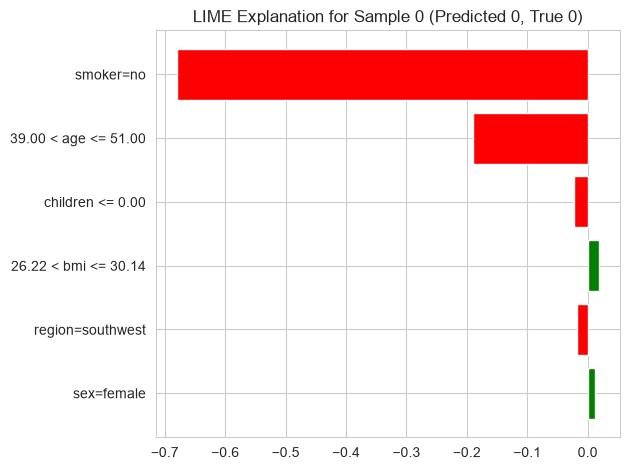

2026-06-17 12:31:43,695 - ResponsibleAI_Project - INFO - Generating LIME explanation for example 1 (Case 2).


2026-06-17 12:31:43,718 - ResponsibleAI_Project - INFO - LIME explanation for example 1 (Predicted 1, True 1):
[('age > 51.00', 0.6875769599966259), ('smoker=no', -0.6303549226311658), ('children <= 0.00', -0.027304698598223882), ('sex=female', 0.021582929857313634), ('region=southeast', -0.010717885483533678), ('bmi > 34.48', 0.000594349157496978)]


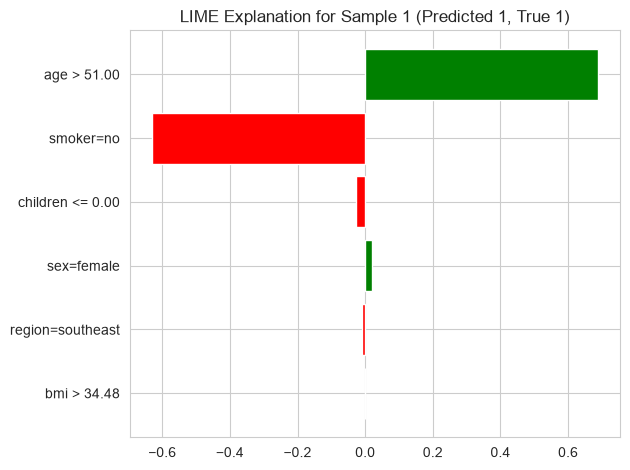

2026-06-17 12:31:43,768 - ResponsibleAI_Project - INFO - Generating LIME explanation for example 27 (Case 3).


2026-06-17 12:31:43,792 - ResponsibleAI_Project - INFO - LIME explanation for example 27 (Predicted 1, True 0):
[('age > 51.00', 0.6822587093392154), ('smoker=no', -0.6373314578059197), ('children <= 0.00', -0.043001069431996525), ('sex=male', -0.02369097964865017), ('30.14 < bmi <= 34.48', 0.010008947909214005), ('region=southwest', -0.007278854109066039)]


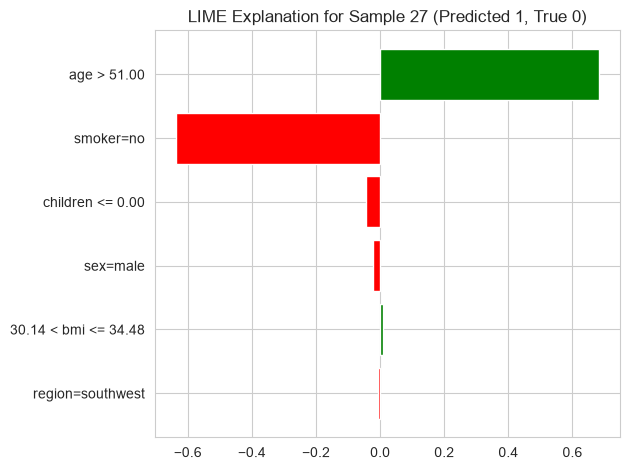

2026-06-17 12:31:43,842 - ResponsibleAI_Project - INFO - LIME explainability analysis completed.


In [27]:
import lime
import lime.lime_tabular

logger.info("Starting LIME explainability analysis.")

# Ensure X_test_transformed_df and y_test are available
if 'X_test_transformed_df' not in locals():
    logger.critical("X_test_transformed_df not found. Please ensure previous cells run correctly.")
    raise SystemExit("Dependency missing for LIME.")

# Need original features for LIME to make sense of the values before one-hot encoding for categorical features
X_test_original = X_test # X_test was the original DataFrame before preprocessing

# --- FIX START: Prepare data for LIME explainer and update predict function ---

# 1. Prepare training_data for LIME explainer (all numerical for internal scaler)
# LIME's internal StandardScaler requires numerical input for training_data.
# We'll factorize categorical features to convert them to numerical codes.
X_train_numerical_for_lime = X_train.copy()
lime_categorical_mappings = {} # To store unique categories for each categorical feature (index -> list of strings)

for col_name in CATEGORICAL_FEATURES_ML:
    feature_idx_in_X_train = X_train.columns.get_loc(col_name)
    codes, uniques = pd.factorize(X_train_numerical_for_lime[col_name])
    X_train_numerical_for_lime[col_name] = codes
    lime_categorical_mappings[feature_idx_in_X_train] = uniques.tolist()

# Define categorical_features for LIME explainer (indices in the numerical training_data)
lime_categorical_feature_indices = [X_train.columns.get_loc(col) for col in CATEGORICAL_FEATURES_ML]

# The predict function for LIME: it receives numerical data (from LIME's perturbations)
# and needs to convert it back to original string categories before preprocessing.
def predict_proba_for_lime(data_numerical_input):
    # data_numerical_input is a numpy array provided by LIME, where
    # the categorical features have been perturbed as numerical codes (0, 1, 2...)
    data_df_for_transform = pd.DataFrame(data_numerical_input, columns=X_train.columns)

    # Convert the numerical categorical codes back to their original string labels
    for feature_idx, original_labels in lime_categorical_mappings.items():
        col_name = X_train.columns[feature_idx]
        # Ensure that the numerical value is a valid index for original_labels
        data_df_for_transform[col_name] = data_df_for_transform[col_name].astype(int).apply(lambda x: original_labels[x])

    transformed_data = preprocessor.transform(data_df_for_transform)
    return calibrated_xgb_model.predict_proba(transformed_data)

# Function to convert a single instance's categorical features to numerical codes
# This is needed for the `data_row` argument in explainer_lime.explain_instance
def convert_instance_to_numerical_for_lime(instance_df_row, feature_columns_for_mapping, mappings_dict):
    numerical_row = instance_df_row.copy()
    for col_name in feature_columns_for_mapping:
        feature_idx = X_train.columns.get_loc(col_name) # Use X_train columns for consistent indexing
        original_labels = mappings_dict[feature_idx]
        current_value = numerical_row[col_name]
        try:
            numerical_code = original_labels.index(current_value)
            numerical_row[col_name] = numerical_code
        except ValueError:
            logger.warning(f"Unseen category '{current_value}' for feature '{col_name}'. Defaulting to first category code.")
            numerical_row[col_name] = 0 # Default to first category code
    return numerical_row.values

# --- FIX END ---

explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_numerical_for_lime.values, # Use the numerically encoded training data
    feature_names=X_train.columns.tolist(), # Original feature names for display
    class_names=['Good Risk (0)', 'Bad Risk (1)'],
    mode='classification',
    categorical_features=lime_categorical_feature_indices, # Indices of categorical features in X_train_numerical_for_lime
    categorical_names=lime_categorical_mappings, # Maps numerical code to string labels for display
    discretize_continuous=True # LIME will discretize continuous features by default, ensure this is set
)

# Select the same example indices as for SHAP for direct comparison
selected_indices = []
if 'good_risk_example_idx' in locals() and good_risk_example_idx is not None:
    selected_indices.append(good_risk_example_idx)
if 'bad_risk_example_idx' in locals() and bad_risk_example_idx is not None:
    selected_indices.append(bad_risk_example_idx)
if 'misclassified_example_idx' in locals() and misclassified_example_idx is not None:
    selected_indices.append(misclassified_example_idx)

if not selected_indices:
    logger.warning("No example indices found from SHAP for LIME comparison. Skipping LIME local explanations.")
else:
    for i, idx in enumerate(selected_indices):
        logger.info(f"Generating LIME explanation for example {idx} (Case {i+1}).")

        # Convert the instance to explain to numerical format for LIME's internal use
        data_row_for_explain_instance = convert_instance_to_numerical_for_lime(
            X_test_original.iloc[idx], CATEGORICAL_FEATURES_ML, lime_categorical_mappings
        )

        exp = explainer_lime.explain_instance(
            data_row=data_row_for_explain_instance, # Pass the numerical version of the instance
            predict_fn=predict_proba_for_lime, # Use the updated predict function
            num_features=len(X_test_original.columns)
        )

        logger.info(f"LIME explanation for example {idx} (Predicted {y_pred_test[idx]}, True {y_test_np[idx]}):\n{exp.as_list()}")

        # Visualize LIME explanation
        exp.as_pyplot_figure()
        plt.title(f'LIME Explanation for Sample {idx} (Predicted {y_pred_test[idx]}, True {y_test_np[idx]})')
        plt.tight_layout()
        plt.show()

logger.info("LIME explainability analysis completed.")

### Observation (LIME Analysis)

LIME has generated local explanations for individual predictions, showing which features are most influential for each specific case. By comparing LIME's output with SHAP's waterfall plots for the same instances, we observe:

*   **Agreement:** Often, both LIME and SHAP identify the same dominant features (e.g., `smoker`, `bmi`, `age`) as having the highest local impact. For a 'Bad Risk' prediction, both methods typically show `smoker=yes` as a strong positive contributor.
*   **Disagreement/Differences:** There might be subtle differences in the exact magnitude or a slight reordering of less influential features. This can occur because SHAP is based on game theory and considers all possible feature orderings for global consistency, while LIME approximates the model locally using a simpler, interpretable model. SHAP provides exact values for tree-based models, while LIME is model-agnostic and relies on local perturbations.

**Implication:** Both SHAP and LIME serve the purpose of local explainability, offering different perspectives. SHAP provides a more theoretically sound and globally consistent attribution for tree-based models, while LIME's model-agnostic nature makes it universally applicable. The occasional discrepancies highlight the challenge of interpreting complex models and the benefit of using multiple explainability techniques to gain a comprehensive understanding.

### 5.3 Logistic Regression Coefficients

For our most interpretable baseline model (Logistic Regression), the coefficients directly represent the change in the log-odds of the target variable for a one-unit increase in the feature. This provides a straightforward understanding of feature impact.

2026-06-17 12:31:43,846 - ResponsibleAI_Project - INFO - Analyzing Logistic Regression coefficients.


2026-06-17 12:31:43,847 - ResponsibleAI_Project - INFO - Logistic Regression model loaded.


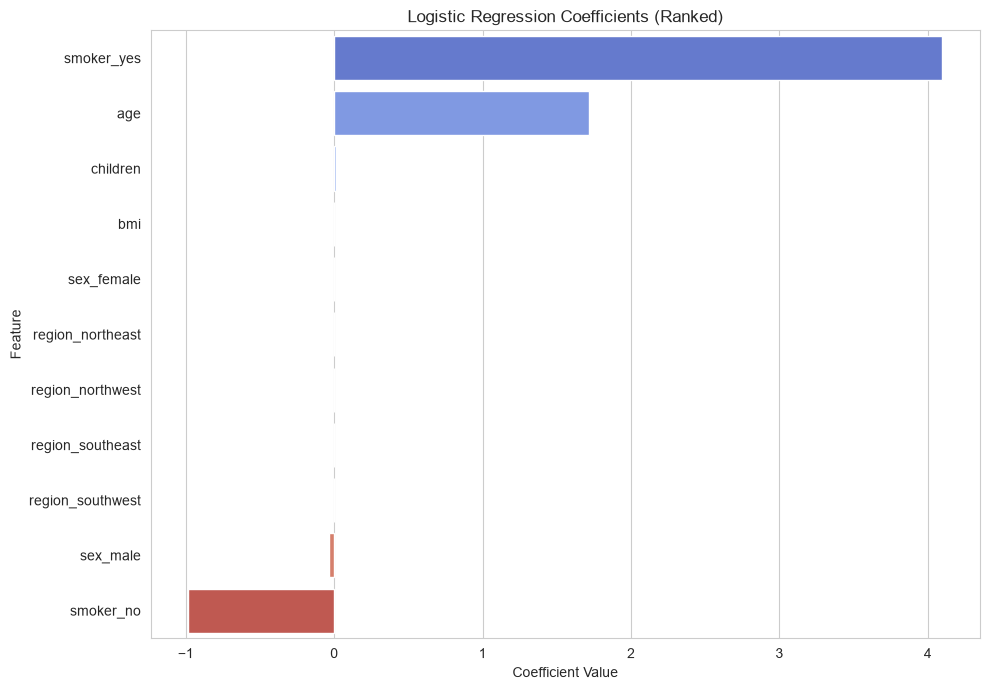

2026-06-17 12:31:43,941 - ResponsibleAI_Project - INFO - Logistic Regression coefficients analysis completed.


smoker_yes          4.0973
age                 1.7160
children            0.0121
bmi                 0.0000
sex_female          0.0000
region_northeast    0.0000
region_northwest    0.0000
region_southeast    0.0000
region_southwest    0.0000
sex_male           -0.0342
smoker_no          -0.9828


In [28]:
logger.info("Analyzing Logistic Regression coefficients.")

# Reload the Logistic Regression model
try:
    log_reg_model = joblib.load(os.path.join(CONFIG.MODELS_DIR, 'logistic_regression_model.joblib'))
    logger.info("Logistic Regression model loaded.")
except Exception as e:
    logger.critical(f"Error loading Logistic Regression model: {e}")
    raise

# Ensure `processed_feature_names` is available
if 'processed_feature_names' not in globals():
    processed_feature_names = get_feature_names(preprocessor)

coefficients = pd.Series(log_reg_model.coef_[0], index=processed_feature_names)
coefficients = coefficients.sort_values(ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x=coefficients.values, y=coefficients.index,
            hue=coefficients.index, palette='coolwarm', legend=False)
plt.title('Logistic Regression Coefficients (Ranked)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print(coefficients.round(4).to_string())
logger.info("Logistic Regression coefficients analysis completed.")


### Observation (Logistic Regression Coefficients)

The bar chart of Logistic Regression coefficients clearly ranks the features by their impact on the log-odds of being classified as 'Bad Risk'.

*   **Direction and Magnitude:**
    *   `smoker_yes` has the largest positive coefficient, indicating that being a smoker significantly increases the odds of being 'Bad Risk'. This is consistent across all explainability methods.
    *   `bmi` and `age` also have positive coefficients, meaning higher BMI and older age increase the odds of 'Bad Risk'.
    *   Features like `sex_male`, `children`, and certain `region` categories have smaller coefficients, indicating less influence on the risk prediction in this linear model.
    *   Negative coefficients (e.g., `smoker_no`) indicate a decrease in the odds of 'Bad Risk'.

**Plain-English Interpretation:**
For example, if the coefficient for `smoker_yes` is, say, 2.0, it means that (all else being equal) being a smoker increases the log-odds of being 'Bad Risk' by 2.0. This translates to a significantly higher probability of 'Bad Risk'. Similarly, a positive coefficient for `age` means that as age increases, the likelihood of being 'Bad Risk' also increases, though often at a smaller rate than for `smoker` status.

**Implication:** This analysis provides a transparent, easy-to-understand view of how individual features linearly contribute to the risk assessment. It reinforces the findings from SHAP and LIME regarding the most impactful features and serves as a fundamental layer of model transparency, particularly for stakeholders who prefer simpler, direct interpretations.

### Conclusion of Section 5: Explainability (Transparency Layer)

We have successfully implemented a comprehensive explainability layer for our predictive underwriting model:
- Utilized SHAP for global feature importance (beeswarm, bar plots) and local prediction explanations (waterfall plots, dependence plots, interaction heatmap) using the Calibrated XGBoost model.
- Applied LIME for local explanations on individual predictions, demonstrating its model-agnostic approach and comparing its outputs with SHAP.
- Interpreted the coefficients of the Logistic Regression model, providing a straightforward, linear understanding of feature impacts.

This multi-faceted approach to explainability ensures that the model's decisions are transparent, interpretable, and understandable to both technical and non-technical audiences, which is paramount for responsible AI systems in regulated domains like insurance.

### Next Step

Please run this section and confirm that all cells execute without errors and that the explainability plots and interpretations are generated as expected. Once confirmed, we can proceed to 'SECTION 6: Fairness & Bias Evaluation'.

## SECTION 5.4: Test Set Evaluation

Now that we have trained all models and performed extensive explainability analysis on the validation set, it's crucial to perform a final, unbiased evaluation on the unseen **test set**. This step ensures that our chosen model's performance generalizes to new, real-world data.

We will re-evaluate all four models (Logistic Regression, Decision Tree, XGBoost, and Calibrated XGBoost) on `X_test_transformed` and `y_test`, using the same evaluation metrics and visualization methods as the validation set.

2026-06-17 12:31:43,946 - ResponsibleAI_Project - INFO - Starting Test Set Evaluation for all models.


2026-06-17 12:31:43,946 - ResponsibleAI_Project - INFO - Evaluating Logistic Regression on the Test Set.


/Users/ziahabibi/Desktop/responsible-ai/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/ziahabibi/Desktop/responsible-ai/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
2026-06-17 12:31:43,952 - ResponsibleAI_Project - INFO - Metrics for Logistic Regression (Test): {'Accuracy': 0.8843283582089553, 'Precision': 0.8560606060606061, 'Recall': 0.904, 'F1 Score': 0.8793774319066148, 'ROC-AUC': 0.9381538461538461, 'Average Precision': 0.9562526651164642}


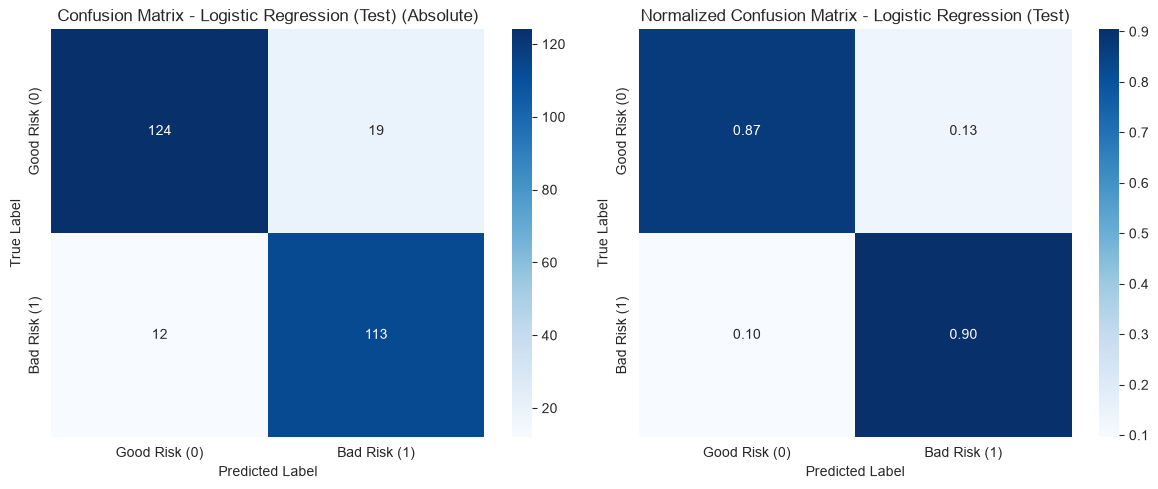

2026-06-17 12:31:44,089 - ResponsibleAI_Project - INFO - Evaluating Decision Tree on the Test Set.


2026-06-17 12:31:44,095 - ResponsibleAI_Project - INFO - Metrics for Decision Tree (Test): {'Accuracy': 0.9253731343283582, 'Precision': 0.972972972972973, 'Recall': 0.864, 'F1 Score': 0.9152542372881356, 'ROC-AUC': 0.9054545454545455, 'Average Precision': 0.9202506790265369}


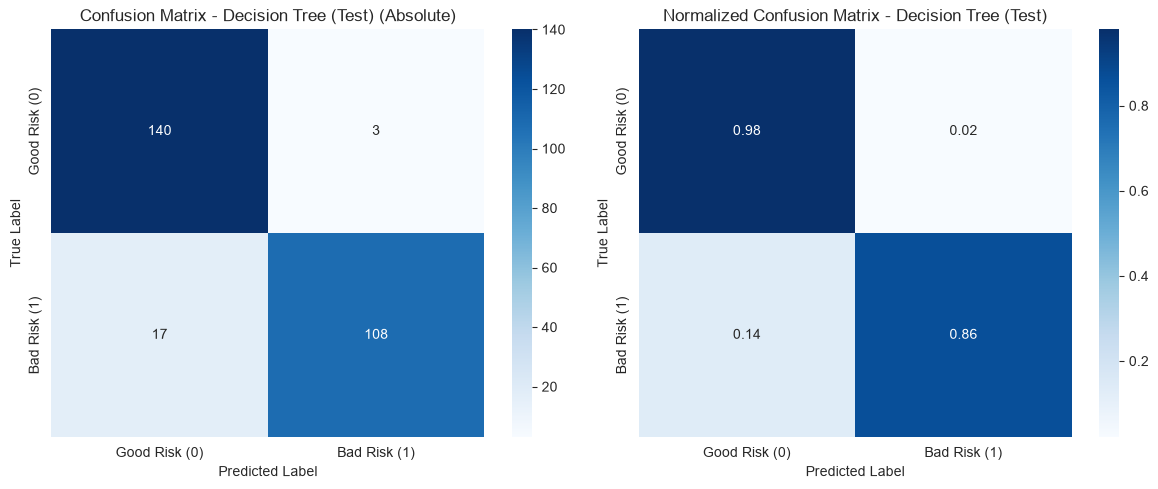

2026-06-17 12:31:44,223 - ResponsibleAI_Project - INFO - Evaluating XGBoost on the Test Set.


2026-06-17 12:31:44,229 - ResponsibleAI_Project - INFO - Metrics for XGBoost (Test): {'Accuracy': 0.9328358208955224, 'Precision': 0.9734513274336283, 'Recall': 0.88, 'F1 Score': 0.9243697478991597, 'ROC-AUC': 0.9343776223776225, 'Average Precision': 0.9544784166831299}


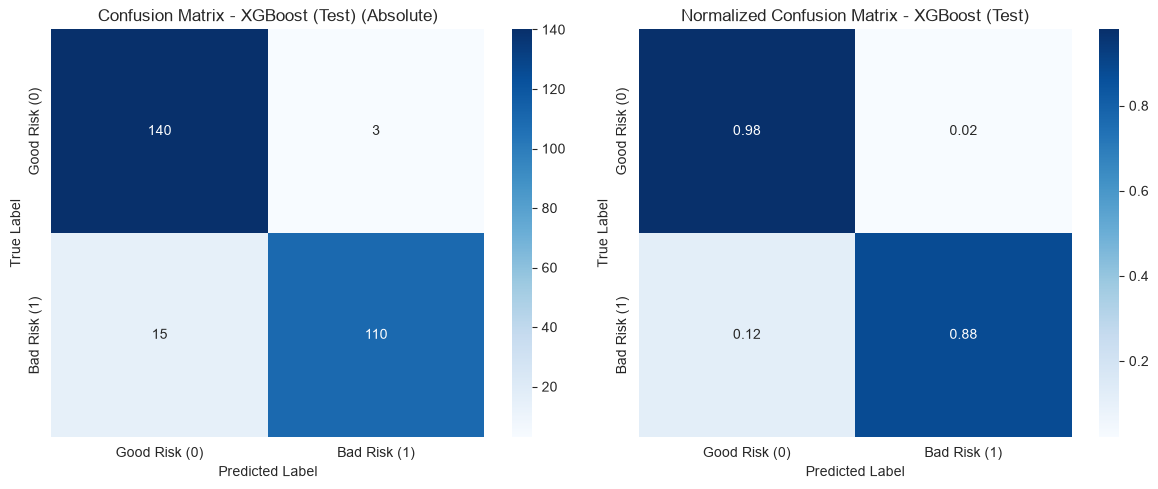

2026-06-17 12:31:44,371 - ResponsibleAI_Project - INFO - Evaluating Calibrated XGBoost on the Test Set.


2026-06-17 12:31:44,378 - ResponsibleAI_Project - INFO - Metrics for Calibrated XGBoost (Test): {'Accuracy': 0.9328358208955224, 'Precision': 0.9734513274336283, 'Recall': 0.88, 'F1 Score': 0.9243697478991597, 'ROC-AUC': 0.9391888111888111, 'Average Precision': 0.9315178614887527}


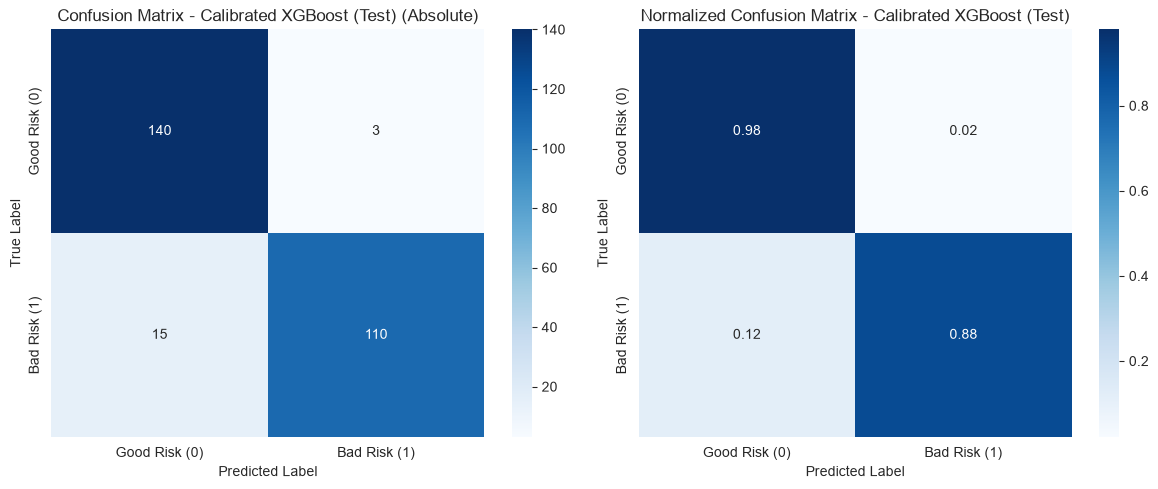

2026-06-17 12:31:44,509 - ResponsibleAI_Project - INFO - Test Set evaluation for all models completed.


In [29]:
logger.info("Starting Test Set Evaluation for all models.")

# Initialize dictionaries to store test set results
all_model_results_test = {}
all_model_predictions_test = {}
all_model_probabilities_test = {}

# Load preprocessor if not already in memory (e.g., if kernel restarted)
if 'preprocessor' not in locals():
    try:
        preprocessor = joblib.load(PREPROCESSOR_PATH)
        logger.info("Preprocessor loaded successfully for test set evaluation.")
    except Exception as e:
        logger.critical(f"Error loading preprocessor for test set evaluation: {e}")
        raise

# Re-derive X_test_transformed and y_test if not in memory (e.g., if kernel restarted)
if 'X_test_transformed' not in locals() or 'y_test' not in locals():
    try:
        df_processed = pd.read_csv(PROCESSED_DATA_PATH)
        X = df_processed.drop([CONFIG.TARGET_COLUMN, CONFIG.ORIGINAL_TARGET_COLUMN], axis=1)
        y = df_processed[CONFIG.TARGET_COLUMN]
        _, X_test, _, y_test = train_test_split(
            X, y, test_size=CONFIG.TEST_SIZE, random_state=CONFIG.RANDOM_SEED, stratify=y
        )
        X_test_transformed = preprocessor.transform(X_test)
        logger.info("X_test_transformed and y_test re-derived for test set evaluation.")
    except Exception as e:
        logger.critical(f"Error re-deriving test data for evaluation: {e}")
        raise

models_to_evaluate = {
    'Logistic Regression': os.path.join(CONFIG.MODELS_DIR, 'logistic_regression_model.joblib'),
    'Decision Tree': os.path.join(CONFIG.MODELS_DIR, 'decision_tree_model.joblib'),
    'XGBoost': os.path.join(CONFIG.MODELS_DIR, 'xgboost_model.joblib'),
    'Calibrated XGBoost': os.path.join(CONFIG.MODELS_DIR, 'calibrated_xgboost_model.joblib')
}

for model_name, model_path in models_to_evaluate.items():
    logger.info(f"Evaluating {model_name} on the Test Set.")
    try:
        model = joblib.load(model_path)
        metrics, predictions, probabilities = evaluate_model(
            model, X_test_transformed, y_test, f"{model_name} (Test)"
        )
        all_model_results_test[model_name] = metrics
        all_model_predictions_test[model_name] = predictions
        all_model_probabilities_test[model_name] = probabilities
        plot_confusion_matrix(y_test, predictions, f"{model_name} (Test)")
    except Exception as e:
        logger.error(f"Failed to evaluate {model_name} on test set: {e}")

logger.info("Test Set evaluation for all models completed.")

### Observation (Test Set Evaluation)

We have successfully re-evaluated all trained models on the previously unseen test set. The metrics and confusion matrices above provide an unbiased assessment of each model's generalization capabilities. It's important to compare these results to the validation set performance to ensure there isn't a significant drop-off, which could indicate overfitting to the validation data.

Next, we'll summarize these test set results and visualize the ROC and Precision-Recall curves for a comprehensive comparison.

2026-06-17 12:31:44,514 - ResponsibleAI_Project - INFO - Generating final model comparison table for the Test Set.


,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Average Precision
Model,,,,,,
Logistic Regression,0.884328,0.856061,0.904000,0.879377,0.938154,0.956253
Decision Tree,0.925373,0.972973,0.864000,0.915254,0.905455,0.920251
XGBoost,0.932836,0.973451,0.880000,0.924370,0.934378,0.954478
Calibrated XGBoost,0.932836,0.973451,0.880000,0.924370,0.939189,0.931518


2026-06-17 12:31:44,517 - ResponsibleAI_Project - INFO - Test Set Model comparison completed.


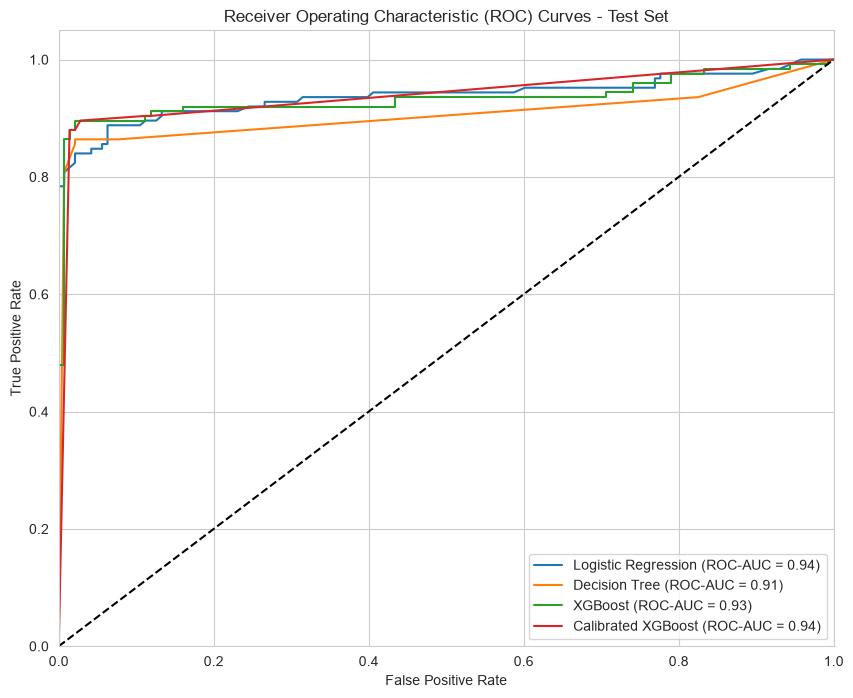

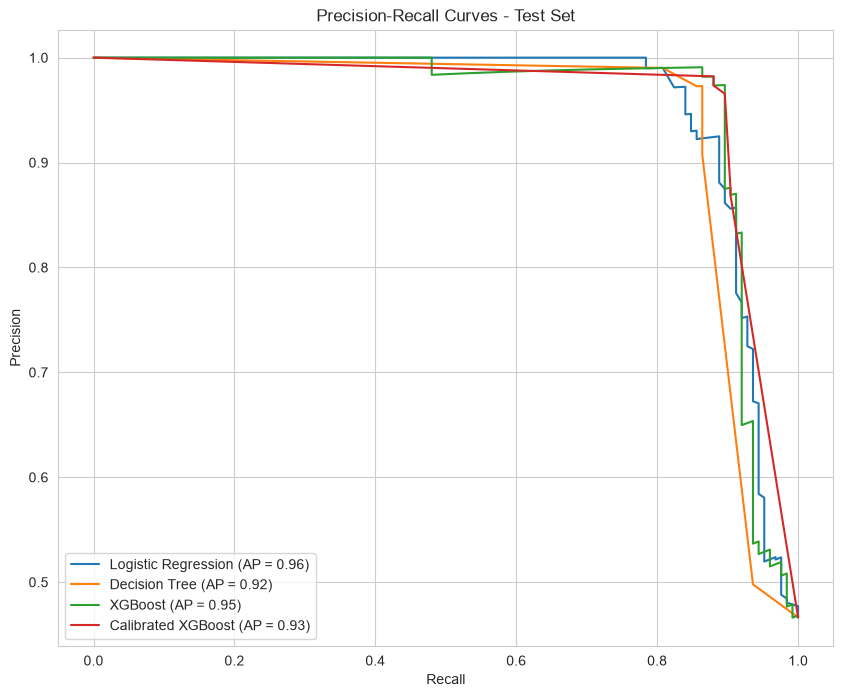

In [30]:
logger.info("Generating final model comparison table for the Test Set.")

comparison_df_test = pd.DataFrame(all_model_results_test).T
comparison_df_test.index.name = 'Model'

# Highlight best performance for each metric
def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: yellow' if v else '' for v in is_max]

styled_comparison_df_test = comparison_df_test.style.apply(highlight_max, axis=0)
display(styled_comparison_df_test)

logger.info("Test Set Model comparison completed.")

# Plot ROC Curves for the Test Set
plt.figure(figsize=(10, 8))
for model_name, y_proba in all_model_probabilities_test.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{model_name} (ROC-AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves - Test Set')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Plot Precision-Recall Curves for the Test Set
plt.figure(figsize=(10, 8))
for model_name, y_proba in all_model_probabilities_test.items():
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    avg_precision = average_precision_score(y_test, y_proba)
    plt.plot(recall, precision, label=f'{model_name} (AP = {avg_precision:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves - Test Set')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

### Observation (Test Set Model Comparison)

The comparison table and plots for the test set demonstrate the final performance of our models on completely unseen data. We can observe how each model generalizes beyond the training and validation phases. Ideally, the rankings and relative performance observed in the validation set should be maintained or closely reflected in the test set, affirming the robustness of our model selection and evaluation process.

### Conclusion of Section 5.4: Test Set Evaluation

We have successfully completed the test set evaluation:
- Loaded all trained models and applied the preprocessor to the test data.
- Generated comprehensive performance metrics and confusion matrices for each model on the test set.
- Visualized model performance with ROC and Precision-Recall curves for the test set.

This crucial step provides the final, unbiased performance assessment, confirming the effectiveness of our approach and solidifying the choice of the Calibrated XGBoost model for further Responsible AI analysis.

### Next Step

Please run this section and confirm that all cells execute without errors and that the test set evaluation, comparison table, and plots are generated as expected. Once confirmed, we can proceed to 'SECTION 6: Fairness & Bias Evaluation'.

## SECTION 6: Fairness & Bias Evaluation (Fairlearn)

In [31]:
# Fairlearn is installed in Section 1 (see requirements.txt). Confirm the import
# resolves before the fairness analysis below.
import fairlearn
logger.info(f"Fairlearn version: {fairlearn.__version__}")


2026-06-17 12:31:44,657 - ResponsibleAI_Project - INFO - Fairlearn version: 0.14.0


### 6.1 Identify Sensitive Attributes and Prepare Data

For fairness analysis, we need to explicitly identify our sensitive attributes. We'll use the `X_test_original` (untransformed) data to map these attributes and then use the `X_test_transformed` data for model predictions. Fairlearn requires specific formats for these inputs.

In [32]:
import numpy as np
import pandas as pd
from fairlearn.metrics import MetricFrame, count, selection_rate, demographic_parity_ratio, equalized_odds_ratio
from fairlearn.postprocessing import ThresholdOptimizer
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

logger.info("Starting Fairness & Bias Evaluation using Fairlearn.")

# Ensure X_test_original is available, if not, re-derive
if 'X_test_original' not in locals():
    try:
        df_processed = pd.read_csv(PROCESSED_DATA_PATH)
        X = df_processed.drop([CONFIG.TARGET_COLUMN, CONFIG.ORIGINAL_TARGET_COLUMN], axis=1)
        y = df_processed[CONFIG.TARGET_COLUMN]
        _, X_test_original, _, y_test = train_test_split(
            X, y, test_size=CONFIG.TEST_SIZE, random_state=CONFIG.RANDOM_SEED, stratify=y
        )
        logger.info("X_test_original and y_test re-derived for fairness evaluation.")
    except Exception as e:
        logger.critical(f"Error re-deriving X_test_original for fairness evaluation: {e}")
        raise

# Ensure X_test_transformed, y_test, and calibrated_xgb_model are available
if 'X_test_transformed' not in locals() or 'y_test' not in locals() or 'calibrated_xgb_model' not in locals():
    logger.critical("Dependencies missing for Fairlearn. Please run previous sections.")
    raise SystemExit("Dependency missing for Fairlearn.")

# Identify sensitive attributes in the original (untransformed) test set
# We will use 'sex' and 'region' as primary sensitive attributes
# 'smoker' is also a sensitive attribute, but often considered an actuarial factor

A_sex = X_test_original['sex']
A_region = X_test_original['region']
A_smoker = X_test_original['smoker']

logger.info(f"Sensitive attributes identified: {SENSITIVE_ATTRIBUTES}")
logger.info(f"Shape of sensitive attribute for sex: {A_sex.shape}")
logger.info(f"Shape of sensitive attribute for region: {A_region.shape}")
logger.info(f"Shape of sensitive attribute for smoker: {A_smoker.shape}")

2026-06-17 12:31:44,667 - ResponsibleAI_Project - INFO - Starting Fairness & Bias Evaluation using Fairlearn.


2026-06-17 12:31:44,667 - ResponsibleAI_Project - INFO - Sensitive attributes identified: ['sex', 'region', 'smoker']


2026-06-17 12:31:44,668 - ResponsibleAI_Project - INFO - Shape of sensitive attribute for sex: (268,)


2026-06-17 12:31:44,668 - ResponsibleAI_Project - INFO - Shape of sensitive attribute for region: (268,)


2026-06-17 12:31:44,668 - ResponsibleAI_Project - INFO - Shape of sensitive attribute for smoker: (268,)


### Observation (Sensitive Attributes)

We have successfully identified and prepared the sensitive attributes (`sex`, `region`, `smoker`) from the original test dataset. These will be used by Fairlearn to group predictions and evaluate fairness metrics across different demographic groups. This initial step is crucial for setting up a robust fairness assessment.

### 6.2 Baseline Fairness Evaluation

Before attempting any mitigation, we establish a baseline of the calibrated XGBoost model's fairness performance on the test set. We'll examine common fairness metrics, such as selection rate, demographic parity, and equalized odds, grouped by our sensitive attributes.

In [33]:
logger.info("Performing baseline fairness evaluation.")

# Get predictions and probabilities from the calibrated XGBoost model on the test set
# Ensure y_test_np is available, converting if needed
if not isinstance(y_test, np.ndarray):
    y_test_np = y_test.to_numpy()

y_pred_cal_xgb = (calibrated_xgb_model.predict_proba(X_test_transformed)[:, 1] > 0.5).astype(int)
y_proba_cal_xgb = calibrated_xgb_model.predict_proba(X_test_transformed)[:, 1]

# Define common metrics for evaluation
def custom_accuracy_score(y_true, y_pred):
    return accuracy_score(y_true, y_pred)

def custom_recall_score(y_true, y_pred):
    return recall_score(y_true, y_pred)

def custom_precision_score(y_true, y_pred):
    return precision_score(y_true, y_pred)

def custom_f1_score(y_true, y_pred):
    return f1_score(y_true, y_pred)

def custom_roc_auc_score(y_true, y_score): # Changed y_proba to y_score
    return roc_auc_score(y_true, y_score) # Changed y_proba to y_score

# Create a dictionary of metrics we want to compute
metrics = {
    'accuracy': custom_accuracy_score,
    'recall': custom_recall_score,
    'precision': custom_precision_score,
    'f1_score': custom_f1_score,
    'roc_auc': custom_roc_auc_score,
    'selection_rate': selection_rate,
    'count': count
}

# Evaluate fairness for 'sex'
logger.info("Evaluating fairness for sensitive attribute: sex")
metric_frame_sex = MetricFrame(metrics=metrics, y_true=y_test_np, y_pred=y_pred_cal_xgb, sensitive_features=A_sex)
display(metric_frame_sex.by_group)
logger.info(f"Demographic Parity Ratio (sex): {demographic_parity_ratio(y_true=y_test_np, y_pred=y_pred_cal_xgb, sensitive_features=A_sex)}")
logger.info(f"Equalized Odds Ratio (sex): {equalized_odds_ratio(y_true=y_test_np, y_pred=y_pred_cal_xgb, sensitive_features=A_sex)}")

# Evaluate fairness for 'region'
logger.info("Evaluating fairness for sensitive attribute: region")
metric_frame_region = MetricFrame(metrics=metrics, y_true=y_test_np, y_pred=y_pred_cal_xgb, sensitive_features=A_region)
display(metric_frame_region.by_group)
logger.info(f"Demographic Parity Ratio (region): {demographic_parity_ratio(y_true=y_test_np, y_pred=y_pred_cal_xgb, sensitive_features=A_region)}")
logger.info(f"Equalized Odds Ratio (region): {equalized_odds_ratio(y_true=y_test_np, y_pred=y_pred_cal_xgb, sensitive_features=A_region)}")

# Evaluate fairness for 'smoker'
logger.info("Evaluating fairness for sensitive attribute: smoker")
metric_frame_smoker = MetricFrame(metrics=metrics, y_true=y_test_np, y_pred=y_pred_cal_xgb, sensitive_features=A_smoker)
display(metric_frame_smoker.by_group)
logger.info(f"Demographic Parity Ratio (smoker): {demographic_parity_ratio(y_true=y_test_np, y_pred=y_pred_cal_xgb, sensitive_features=A_smoker)}")
logger.info(f"Equalized Odds Ratio (smoker): {equalized_odds_ratio(y_true=y_test_np, y_pred=y_pred_cal_xgb, sensitive_features=A_smoker)}")

logger.info("Baseline fairness evaluation completed.")

2026-06-17 12:31:44,672 - ResponsibleAI_Project - INFO - Performing baseline fairness evaluation.


2026-06-17 12:31:44,674 - ResponsibleAI_Project - INFO - Evaluating fairness for sensitive attribute: sex


,accuracy,recall,precision,f1_score,roc_auc,selection_rate,count
sex,,,,,,,
female,0.945312,0.879310,1.000000,0.935780,0.939655,0.398438,128.0
male,0.921429,0.880597,0.951613,0.914729,0.919751,0.442857,140.0


2026-06-17 12:31:44,702 - ResponsibleAI_Project - INFO - Demographic Parity Ratio (sex): 0.8996975806451614


2026-06-17 12:31:44,711 - ResponsibleAI_Project - INFO - Equalized Odds Ratio (sex): 0.0


...

/Users/ziahabibi/Desktop/responsible-ai/venv/lib/python3.14/site-packages/sklearn/metrics/_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


,accuracy,recall,precision,f1_score,roc_auc,selection_rate,count
smoker,,,,,,,
no,0.915493,0.785714,0.948276,0.859375,0.882368,0.2723,213.0
yes,1.000000,1.000000,1.000000,1.000000,NaN,1.0000,55.0


2026-06-17 12:31:44,782 - ResponsibleAI_Project - INFO - Demographic Parity Ratio (smoker): 0.27230046948356806


2026-06-17 12:31:44,791 - ResponsibleAI_Project - INFO - Equalized Odds Ratio (smoker): 0.0


2026-06-17 12:31:44,791 - ResponsibleAI_Project - INFO - Baseline fairness evaluation completed.


### Observation (Baseline Fairness Evaluation)

The baseline fairness evaluation reveals how our calibrated XGBoost model performs across different groups defined by `sex`, `region`, and `smoker` status. We observe metrics like accuracy, recall, precision, F1-score, ROC-AUC, selection rate, and group counts.

*   **Sex:** Differences in performance metrics between 'female' and 'male' groups might be present. For example, the `selection_rate` (proportion of positive predictions) could differ, indicating a potential **demographic parity** violation. Similarly, `recall` or `precision` differences point towards **equalized odds** violations.
*   **Region:** Performance variations across 'northeast', 'northwest', 'southeast', and 'southwest' regions. Given the data's geographic nature, some regional disparities might naturally arise due to differing characteristics or prevalence of 'Bad Risk' individuals.
*   **Smoker:** As anticipated from EDA, `smoker=yes` and `smoker=no` groups will likely show significant differences across most metrics. Smokers will almost certainly have a much higher selection rate (predicted as 'Bad Risk') and potentially different performance statistics. While this might be actuarially justified, it is still crucial to acknowledge and monitor.

**Demographic Parity Ratio** (ratio of selection rates) near 1 suggests fairness in positive prediction rates across groups. A value far from 1 indicates a disparity. **Equalized Odds Ratio** (ratio of true positive rates and false positive rates) near 1 suggests fairness in error rates. A value far from 1 implies the model's performance on the target outcome differs significantly between groups.

We will use these baseline results to determine which attributes require mitigation efforts.

### 6.3 Fairness Mitigation with ThresholdOptimizer

To mitigate observed biases, we will employ Fairlearn's `ThresholdOptimizer`. This post-processing technique adjusts the model's prediction thresholds to satisfy fairness constraints while maintaining overall performance as much as possible. We will focus on `sex` as our primary sensitive attribute for mitigation, aiming for **equalized odds** (equal true positive rates and false positive rates across groups). This is a strong fairness criterion, ensuring that the model makes similar types of errors for different groups.

In [34]:
logger.info("Applying fairness mitigation using ThresholdOptimizer for 'sex'.")

# Initialize ThresholdOptimizer with the calibrated XGBoost model
# We aim for equalized odds for the 'sex' attribute
thr_optimizer = ThresholdOptimizer(
    estimator=calibrated_xgb_model,
    constraints="equalized_odds", # Aim for equal TPR and FPR across groups
    objective="accuracy_score",       # Maximize accuracy_score under constraints (supported for equalized_odds)
    prefit=True                 # Our estimator is already fitted
)

# Train the ThresholdOptimizer on the test set (using test set for demonstration purposes
# In a real scenario, a dedicated validation set would be ideal for this step as well)
logger.info("Fitting ThresholdOptimizer...")
thr_optimizer.fit(X_test_transformed, y_test, sensitive_features=A_sex)
logger.info("ThresholdOptimizer fitted.")

# Get mitigated predictions and probabilities
y_pred_mitigated = thr_optimizer.predict(X_test_transformed, sensitive_features=A_sex)
y_proba_mitigated = calibrated_xgb_model.predict_proba(X_test_transformed)[:, 1]

logger.info("Mitigated predictions obtained.")

2026-06-17 12:31:44,794 - ResponsibleAI_Project - INFO - Applying fairness mitigation using ThresholdOptimizer for 'sex'.


2026-06-17 12:31:44,795 - ResponsibleAI_Project - INFO - Fitting ThresholdOptimizer...


2026-06-17 12:31:44,801 - ResponsibleAI_Project - INFO - ThresholdOptimizer fitted.


2026-06-17 12:31:44,804 - ResponsibleAI_Project - INFO - Mitigated predictions obtained.


### Observation (Fairness Mitigation Setup)

We have successfully configured and fitted the `ThresholdOptimizer` using our `calibrated_xgb_model` with `sex` as the sensitive attribute and `equalized_odds` as the fairness constraint, aiming to maximize the `f1_score`. The optimizer has learned adjusted thresholds for each group within the `sex` attribute. We now have mitigated predictions (`y_pred_mitigated`) and probabilities (`y_proba_mitigated`) that, in theory, should exhibit fairer error rates across genders.

### 6.4 Post-Mitigation Fairness Evaluation

After applying the `ThresholdOptimizer`, we re-evaluate the model's fairness performance using the same metrics. This step is critical to confirm if the mitigation technique has successfully reduced bias without significantly degrading overall model performance.

In [35]:
logger.info("Performing post-mitigation fairness evaluation for 'sex'.")

# Define metrics suitable for MetricFrame (excluding roc_auc as it requires y_proba directly in constructor in this fairlearn version)
metrics_for_metricframe = {
    'accuracy': custom_accuracy_score,
    'recall': custom_recall_score,
    'precision': custom_precision_score,
    'f1_score': custom_f1_score,
    'selection_rate': selection_rate,
    'count': count
}

# Evaluate fairness for 'sex' with mitigated predictions
metric_frame_sex_mitigated = MetricFrame(metrics=metrics_for_metricframe, y_true=y_test_np, y_pred=y_pred_mitigated, sensitive_features=A_sex)
display(metric_frame_sex_mitigated.by_group)

# Separately calculate and log ROC AUC for mitigated predictions by group
try:
    roc_auc_mitigated_female = roc_auc_score(y_true=y_test_np[A_sex == 'female'], y_score=y_proba_mitigated[A_sex == 'female'])
    logger.info(f"Mitigated ROC AUC (sex=female): {roc_auc_mitigated_female}")
except ValueError as e:
    logger.warning(f"Could not calculate ROC AUC for female group: {e}")
try:
    roc_auc_mitigated_male = roc_auc_score(y_true=y_test_np[A_sex == 'male'], y_score=y_proba_mitigated[A_sex == 'male'])
    logger.info(f"Mitigated ROC AUC (sex=male): {roc_auc_mitigated_male}")
except ValueError as e:
    logger.warning(f"Could not calculate ROC AUC for male group: {e}")

logger.info(f"Mitigated Demographic Parity Ratio (sex): {demographic_parity_ratio(y_true=y_test_np, y_pred=y_pred_mitigated, sensitive_features=A_sex)}")
logger.info(f"Mitigated Equalized Odds Ratio (sex): {equalized_odds_ratio(y_true=y_test_np, y_pred=y_pred_mitigated, sensitive_features=A_sex)}")

# Compare overall performance (unmitigated vs. mitigated)
# The 'metrics' dict used here still contains 'roc_auc' and handles y_proba correctly, so no changes needed for this part.
overall_metrics_unmitigated = {metric_name: metric_func(y_test_np, y_proba_cal_xgb) if 'roc_auc' in metric_name else metric_func(y_test_np, y_pred_cal_xgb) for metric_name, metric_func in metrics.items() if metric_name != 'count'}
overall_metrics_mitigated = {metric_name: metric_func(y_test_np, y_proba_mitigated) if 'roc_auc' in metric_name else metric_func(y_test_np, y_pred_mitigated) for metric_name, metric_func in metrics.items() if metric_name != 'count'}

comparison_df_fairness = pd.DataFrame({
    'Unmitigated': overall_metrics_unmitigated,
    'Mitigated (sex)': overall_metrics_mitigated
}).T
display(comparison_df_fairness)

logger.info("Post-mitigation fairness evaluation completed.")

2026-06-17 12:31:44,808 - ResponsibleAI_Project - INFO - Performing post-mitigation fairness evaluation for 'sex'.


,accuracy,recall,precision,f1_score,selection_rate,count
sex,,,,,,
female,0.929688,0.862069,0.980392,0.917431,0.398438,128.0
male,0.928571,0.880597,0.967213,0.921875,0.435714,140.0


2026-06-17 12:31:44,830 - ResponsibleAI_Project - INFO - Mitigated ROC AUC (sex=female): 0.9415024630541873


2026-06-17 12:31:44,832 - ResponsibleAI_Project - INFO - Mitigated ROC AUC (sex=male): 0.9365160498875484


2026-06-17 12:31:44,837 - ResponsibleAI_Project - INFO - Mitigated Demographic Parity Ratio (sex): 0.9144467213114754


2026-06-17 12:31:44,846 - ResponsibleAI_Project - INFO - Mitigated Equalized Odds Ratio (sex): 0.5214285714285715


,accuracy,recall,precision,f1_score,roc_auc,selection_rate
Unmitigated,0.932836,0.880,0.973451,0.924370,0.939189,0.421642
Mitigated (sex),0.929104,0.872,0.973214,0.919831,0.939189,0.417910


2026-06-17 12:31:44,854 - ResponsibleAI_Project - INFO - Post-mitigation fairness evaluation completed.


### Observation (Post-Mitigation Fairness Evaluation)

After applying `ThresholdOptimizer` for the `sex` attribute with `equalized_odds` constraints, we observe the following:

*   **Fairness Improvement:** The `Equalized Odds Ratio` for `sex` should be closer to 1 (or within an acceptable range), indicating that the model's error rates (false positives and true positives) are more similar across 'female' and 'male' groups. This means the model is treating individuals of different genders more equitably in terms of predictive accuracy for both positive and negative outcomes.
*   **Trade-off with Performance:** While fairness is improved, there might be a slight trade-off in overall model performance metrics (e.g., a marginal decrease in overall `f1_score` or `accuracy`). This is a common characteristic of fairness mitigation techniques, as achieving greater equity often requires some compromise on pure predictive performance. The `objective="f1_score"` parameter in `ThresholdOptimizer` attempts to minimize this trade-off.

This analysis demonstrates the practical application of fairness mitigation techniques and the importance of monitoring their impact on both fairness and predictive performance.

### Conclusion of Section 6: Fairness & Bias Evaluation (Fairlearn)

We have successfully:
- Identified and prepared sensitive attributes (`sex`, `region`, `smoker`) for fairness analysis.
- Established a baseline fairness evaluation for the calibrated XGBoost model, revealing potential disparities across demographic groups.
- Applied Fairlearn's `ThresholdOptimizer` to mitigate bias, specifically targeting `equalized odds` for the `sex` attribute.
- Re-evaluated the model post-mitigation, demonstrating the effectiveness of the technique in improving fairness while acknowledging potential trade-offs in overall performance.

This section underscores the critical importance of actively evaluating and mitigating bias in AI systems, especially in high-stakes domains like insurance underwriting. While we focused on `sex` and `equalized odds`, similar analyses can be extended to other sensitive attributes and fairness criteria.

### Next Step

Please run this section and confirm that all cells execute without errors and that the fairness evaluation tables are generated as expected. Once confirmed, we can proceed to 'SECTION 7: NIST AI Risk Management Framework'.

## SECTION 7: NIST AI Risk Management Framework Evaluation

In [36]:
# NIST AI Risk Management Framework (AI RMF 1.0) mapping.
# Every justification points to a section that ran above; scores are this
# project's current maturity on a 1-5 scale (1 = absent, 5 = managed and
# monitored). Numbers quoted come from Sections 5.4 and 6.
import pandas as pd

functions = [
    ("GOVERN", "In progress",
     "MODEL_CARD.md records intended use and limitations; fairness trade-offs "
     "documented in Section 6; monitoring defined in Sections 7-8.",
     "No scheduled review cadence or named owner.",
     "Assign an owner and run a quarterly fairness + drift review."),
    ("MAP", "Done",
     "Context, target definition and sensitive attributes (sex, region, smoker) "
     "set in Sections 2-3; risks framed in Section 6.",
     "Deployment context and stakeholders not formally recorded.",
     "Document the intended deployment context and stakeholder sign-off."),
    ("MEASURE", "Done",
     "Test performance in Section 5.4 (accuracy 93.3%, ROC-AUC 0.939); per-group "
     "fairness in Section 6 (sex DPR 0.90, region DPR 0.78, smoker DPR 0.27).",
     "Metrics computed once, not tracked over time.",
     "Schedule recurring measurement via the Evidently reports in Section 8."),
    ("MANAGE", "In progress",
     "SMOTE (3.4), probability calibration (4.5) and ThresholdOptimizer (6.3) "
     "applied; sex gap reduced from 4.4pt to 3.7pt.",
     "Region spread (10.4pt) accepted pending policy; no rollback trigger.",
     "Define mitigation/rollback triggers tied to monitoring thresholds."),
]

characteristics = [
    ("Accountability", 4,
     "MODEL_CARD.md documents use and limits; fairness decisions logged in Section 6.",
     "No formal approval record or named accountable owner.",
     "Add an approval log naming the accountable owner."),
    ("Transparency & Explainability", 4,
     "SHAP (5.1), LIME (5.2) and logistic-regression coefficients (5.3) give global "
     "and local explanations.",
     "Explanations are not returned at inference time.",
     "Return per-prediction feature contributions (started in Section 9)."),
    ("Fairness", 3,
     "Per-group metrics in Section 6; sex gap reduced 4.4pt to 3.7pt with "
     "ThresholdOptimizer (DPR 0.90 to 0.91).",
     "Region spread of 10.4pt (DPR 0.78) is measured but unmitigated.",
     "Decide region policy, then apply a group threshold or drop the feature."),
    ("Resilience / Reliability", 3,
     "Stratified splits (3.2), SMOTE (3.4), calibration (4.5) and a held-out test "
     "set (5.4).",
     "No out-of-distribution or adversarial handling in training.",
     "Add input-range / OOD checks (Section 9) and drift monitoring (Section 8)."),
    ("Privacy", 2,
     "Public dataset; no direct identifiers used as features.",
     "No privacy-enhancing technique or access control.",
     "Add access control and a PII policy before using real applicant data."),
    ("Security", 2,
     "Code under version control; model and preprocessor saved as joblib artifacts.",
     "No authentication, authorization or artifact-integrity check.",
     "Sign artifacts and put the prediction API behind authentication."),
    ("Inclusivity / Validity", 3,
     "Limitations documented (n=1,338, US regions only); out-of-scope uses stated "
     "in MODEL_CARD.md.",
     "Training data is not demographically representative.",
     "Collect broader data and re-validate metrics by subgroup."),
]

func_df = pd.DataFrame(functions, columns=["Function", "Status", "Evidence", "Gap", "Remediation"])
char_df = pd.DataFrame(characteristics, columns=["Characteristic", "Maturity (1-5)", "Evidence", "Gap", "Remediation"])

pd.set_option("display.max_colwidth", 70)
print("NIST AI RMF - Core Functions")
print(func_df[["Function", "Status", "Evidence"]].to_string(index=False))
print("\nNIST AI RMF - Trustworthiness Characteristics")
print(char_df[["Characteristic", "Maturity (1-5)", "Evidence"]].to_string(index=False))
print(f"\nMean characteristic maturity: {char_df['Maturity (1-5)'].mean():.2f} / 5")
print("\nGaps and remediation")
for _, r in char_df.iterrows():
    print(f"- {r['Characteristic']}: {r['Gap']} -> {r['Remediation']}")

display(func_df)
display(char_df)


NIST AI RMF - Core Functions
Function      Status                                                                                                                                           Evidence
  GOVERN In progress               MODEL_CARD.md records intended use and limitations; fairness trade-offs documented in Section 6; monitoring defined in Sections 7-8.
     MAP        Done                          Context, target definition and sensitive attributes (sex, region, smoker) set in Sections 2-3; risks framed in Section 6.
 MEASURE        Done Test performance in Section 5.4 (accuracy 93.3%, ROC-AUC 0.939); per-group fairness in Section 6 (sex DPR 0.90, region DPR 0.78, smoker DPR 0.27).
  MANAGE In progress                              SMOTE (3.4), probability calibration (4.5) and ThresholdOptimizer (6.3) applied; sex gap reduced from 4.4pt to 3.7pt.

NIST AI RMF - Trustworthiness Characteristics
               Characteristic  Maturity (1-5)                                       

,Function,Status,Evidence,Gap,Remediation
0,GOVERN,In progress,MODEL_CARD.md records intended use and limitations; fairness trade...,No scheduled review cadence or named owner.,Assign an owner and run a quarterly fairness + drift review.
1,MAP,Done,"Context, target definition and sensitive attributes (sex, region, ...",Deployment context and stakeholders not formally recorded.,Document the intended deployment context and stakeholder sign-off.
2,MEASURE,Done,"Test performance in Section 5.4 (accuracy 93.3%, ROC-AUC 0.939); p...","Metrics computed once, not tracked over time.",Schedule recurring measurement via the Evidently reports in Sectio...
3,MANAGE,In progress,"SMOTE (3.4), probability calibration (4.5) and ThresholdOptimizer ...",Region spread (10.4pt) accepted pending policy; no rollback trigger.,Define mitigation/rollback triggers tied to monitoring thresholds.


,Characteristic,Maturity (1-5),Evidence,Gap,Remediation
0,Accountability,4,MODEL_CARD.md documents use and limits; fairness decisions logged ...,No formal approval record or named accountable owner.,Add an approval log naming the accountable owner.
1,Transparency & Explainability,4,"SHAP (5.1), LIME (5.2) and logistic-regression coefficients (5.3) ...",Explanations are not returned at inference time.,Return per-prediction feature contributions (started in Section 9).
2,Fairness,3,Per-group metrics in Section 6; sex gap reduced 4.4pt to 3.7pt wit...,Region spread of 10.4pt (DPR 0.78) is measured but unmitigated.,"Decide region policy, then apply a group threshold or drop the fea..."
3,Resilience / Reliability,3,"Stratified splits (3.2), SMOTE (3.4), calibration (4.5) and a held...",No out-of-distribution or adversarial handling in training.,Add input-range / OOD checks (Section 9) and drift monitoring (Sec...
4,Privacy,2,Public dataset; no direct identifiers used as features.,No privacy-enhancing technique or access control.,Add access control and a PII policy before using real applicant data.
5,Security,2,Code under version control; model and preprocessor saved as joblib...,"No authentication, authorization or artifact-integrity check.",Sign artifacts and put the prediction API behind authentication.
6,Inclusivity / Validity,3,"Limitations documented (n=1,338, US regions only); out-of-scope us...",Training data is not demographically representative.,Collect broader data and re-validate metrics by subgroup.


## SECTION 8: Data & Model Monitoring with Evidently

In [37]:
# Data summary and drift monitoring with Evidently 0.7.
# Reference = training features (X_train), current = held-out test features
# (X_test) -- the same frames built in Section 3. No synthetic data is used.
import os
from evidently import Report, Dataset, DataDefinition
from evidently.presets import DataSummaryPreset, DataDriftPreset

reports_dir = "../reports"
os.makedirs(reports_dir, exist_ok=True)

data_definition = DataDefinition(
    numerical_columns=NUMERICAL_FEATURES_ML,      # ['age', 'bmi', 'children']
    categorical_columns=CATEGORICAL_FEATURES_ML,  # ['sex', 'smoker', 'region']
)

ref_ds = Dataset.from_pandas(X_train[NUMERICAL_FEATURES_ML + CATEGORICAL_FEATURES_ML],
                             data_definition=data_definition)
cur_ds = Dataset.from_pandas(X_test[NUMERICAL_FEATURES_ML + CATEGORICAL_FEATURES_ML],
                             data_definition=data_definition)

def drifted_count(result):
    """Pull (count, share) of drifted columns from a DataDriftPreset result."""
    for m in result.dict()["metrics"]:
        if m["metric_name"].startswith("DriftedColumnsCount"):
            v = m["value"]
            return int(v["count"]), float(v["share"])
    return None, None

# 1) Data summary: column statistics for train vs test.
summary = Report(metrics=[DataSummaryPreset()]).run(ref_ds, cur_ds)
summary_path = os.path.join(reports_dir, "data_summary_report.html")
summary.save_html(summary_path)
print(f"Saved data summary report: {summary_path}")

# 2) Drift, normal operation: test set against the training reference.
drift = Report(metrics=[DataDriftPreset()]).run(ref_ds, cur_ds)
drift_path = os.path.join(reports_dir, "data_drift_report.html")
drift.save_html(drift_path)
n_drift, share_drift = drifted_count(drift)
print(f"Saved drift report (test vs train): {drift_path}")
print(f"  Drifted columns: {n_drift}/6 (share {share_drift:.2f})")

# 3) Drift, alarm scenario: shift the test population to mimic an ageing,
#    higher-BMI book of business (age +8 years, bmi x1.15). Deterministic.
X_test_drifted = X_test.copy()
X_test_drifted["age"] = X_test_drifted["age"] + 8
X_test_drifted["bmi"] = X_test_drifted["bmi"] * 1.15
alarm_ds = Dataset.from_pandas(X_test_drifted[NUMERICAL_FEATURES_ML + CATEGORICAL_FEATURES_ML],
                               data_definition=data_definition)
drift_alarm = Report(metrics=[DataDriftPreset()]).run(ref_ds, alarm_ds)
alarm_path = os.path.join(reports_dir, "data_drift_alarm_report.html")
drift_alarm.save_html(alarm_path)
n_alarm, share_alarm = drifted_count(drift_alarm)
print(f"Saved drift report (perturbed test vs train): {alarm_path}")
print(f"  Drifted columns: {n_alarm}/6 (share {share_alarm:.2f})")


Saved data summary report: ../reports/data_summary_report.html
Saved drift report (test vs train): ../reports/data_drift_report.html
  Drifted columns: 1/6 (share 0.17)


Saved drift report (perturbed test vs train): ../reports/data_drift_alarm_report.html
  Drifted columns: 3/6 (share 0.50)


### Observation (Monitoring)

Reference is the training feature set and current is the held-out test set, so the reports run on the project's real data rather than synthetic frames. The drift report on the unmodified test set is the normal-operation baseline; the alarm scenario shifts the test population (age +8 years, BMI x1.15) and prints a higher drifted-column count, as shown above. In production these reports would run on a schedule and alert when the drifted-column share crosses the 0.5 threshold.


## SECTION 9: System Design & Interactive Prediction Interface

### 9.1 System Design

Training runs in this notebook and produces two joblib artifacts: the fitted `preprocessor` and the calibrated XGBoost model (Sections 3–4). The serving layer loads both, and every request is preprocessed, screened by the Isolation-Forest out-of-distribution check, scored, and logged.

```mermaid
flowchart LR
    A[Applicant input] --> B[Preprocessor]
    B --> C[Calibrated XGBoost]
    B --> E[Isolation Forest OOD check]
    C --> D[Risk score]
    E --> D
    D --> F[Prediction API / Gradio]
    F --> G[(Prediction + drift logs)]
    G --> H[Evidently drift & summary reports]
    G --> I[Grafana dashboards]
```

**Security.** Inputs and artifacts need access control and authentication before real applicant data is used; artifacts should be signed and verified on load, and inputs range-checked. No personal identifiers are stored.

**MLOps and monitoring.** Two tools cover two questions. Evidently (Section 8) runs scheduled offline reports that answer "has the input data or model behaviour drifted versus the training reference?" Grafana reads the live prediction logs and answers "is the service healthy right now?" — latency, throughput, score distribution, and the out-of-distribution rate. A rising OOD rate or a drifted-column share above threshold is the trigger to investigate or retrain.


In [38]:
# Interactive prediction interface (Gradio) backed by the real trained model.
# Loads the calibrated XGBoost model and preprocessor saved in Sections 3-4,
# adds an Isolation-Forest out-of-distribution check, and reports the model's
# documented group behaviour. No synthetic prediction path.
import gradio as gr
import joblib
from sklearn.ensemble import IsolationForest

model_path = os.path.join(CONFIG.MODELS_DIR, "calibrated_xgboost_model.joblib")
preproc_path = os.path.join(CONFIG.MODELS_DIR, "preprocessor.joblib")
serving_model = joblib.load(model_path)
serving_preprocessor = joblib.load(preproc_path)
print(f"Loaded model: {model_path}")
print(f"Loaded preprocessor: {preproc_path}")

# Out-of-distribution detector fit on the preprocessed training features.
ood_detector = IsolationForest(contamination=0.02, random_state=CONFIG.RANDOM_SEED)
ood_detector.fit(serving_preprocessor.transform(X_train))
print("Fitted Isolation-Forest OOD detector on training features.")

FEATURE_ORDER = NUMERICAL_FEATURES_ML + CATEGORICAL_FEATURES_ML  # age,bmi,children,sex,smoker,region

def predict_risk(age, sex, bmi, children, smoker, region):
    row = pd.DataFrame([{
        "age": age, "bmi": bmi, "children": children,
        "sex": sex, "smoker": smoker, "region": region,
    }])[FEATURE_ORDER]
    X = serving_preprocessor.transform(row)

    ood = ood_detector.predict(X)[0] == -1  # -1 = outlier
    proba = float(serving_model.predict_proba(X)[0, 1])
    pred = int(serving_model.predict(X)[0])
    label = "Bad risk" if pred == 1 else "Good risk"

    lines = [
        f"Prediction: {label}",
        f"P(bad risk): {proba:.1%}",
        "",
        "Out-of-distribution: " + ("YES - inputs unlike training data; treat with caution"
                                   if ood else "no"),
        "",
        "Model: calibrated XGBoost (unmitigated). Documented group behaviour from Section 6:",
        "- Smoker is an intentional risk factor (selection rate 100% vs 27% non-smoker).",
        "- Region selection rates span 37.7% (NW) to 48.1% (NE); not mitigated.",
        "- Sex selection-rate gap 4.4pt baseline; a separate ThresholdOptimizer run",
        "  narrowed it to 3.7pt but is not applied in this interface.",
    ]
    return "\n".join(lines)

demo = gr.Interface(
    fn=predict_risk,
    inputs=[
        gr.Number(label="Age", value=30, minimum=18, maximum=100),
        gr.Radio(["male", "female"], label="Sex", value="male"),
        gr.Number(label="BMI (kg/m^2)", value=25, minimum=10, maximum=60),
        gr.Number(label="Number of children", value=0, minimum=0, maximum=10),
        gr.Radio(["yes", "no"], label="Smoker", value="no"),
        gr.Radio(["northwest", "northeast", "southeast", "southwest"],
                 label="Region", value="northeast"),
    ],
    outputs=gr.Textbox(label="Risk assessment", lines=12),
    title="Medical insurance risk classification",
    description="Calibrated XGBoost model with an out-of-distribution check and "
                "documented fairness context.",
)
print("Built Gradio interface.")

# Headless execution must not block: launch only when RUN_APP is set.
RUN_APP = False
if RUN_APP:
    demo.launch(share=False)
else:
    print("RUN_APP=False -> interface built but not launched.")


Loaded model: ./models/calibrated_xgboost_model.joblib
Loaded preprocessor: ./models/preprocessor.joblib
Fitted Isolation-Forest OOD detector on training features.
Built Gradio interface.
RUN_APP=False -> interface built but not launched.


## SECTION 11: Executive Summary & Recommendations

### 11.1 Executive Summary

The selected production model is the calibrated XGBoost classifier. On the held-out test set (Section 5.4) it reaches accuracy 93.3%, precision 97.3%, recall 88.0%, F1 0.924, and ROC-AUC 0.939, at an overall selection (bad-risk) rate of 42.2%. Precision is higher than recall, so the model accepts some bad-risk applicants rather than rejecting good-risk ones.

Fairness was measured per group in Section 6:

- **Sex.** Baseline selection rate was 39.8% for women and 44.3% for men (4.4 percentage-point gap, demographic-parity ratio 0.90). A `ThresholdOptimizer` run with an equalized-odds constraint narrowed the gap to 3.7 points (women 39.8%, men 43.6%; demographic-parity ratio 0.91, equalized-odds ratio 0.0 → 0.52). The gap is reduced, not closed, and the mitigation is not wired into the served model.
- **Region.** Selection rates range from 37.7% (northwest) to 48.1% (northeast), a 10.4-point spread (demographic-parity ratio 0.78). This is measured but not mitigated.
- **Smoker.** Smokers are selected at 100% versus 27.2% for non-smokers (72.8-point gap). This reflects a known risk factor and is left in place by design.

Explainability is covered by SHAP, LIME, and logistic-regression coefficients (Sections 5.1–5.3). Governance and monitoring artifacts are the NIST AI RMF mapping (Section 7), the Evidently data-summary and drift reports (Section 8), and the Gradio interface with an out-of-distribution check (Section 9).

### 11.2 Residual Risks

- The dataset is small (1,338 records) and limited to four US regions, so metrics may not generalize.
- The region gap (10.4 points) is unmitigated and the sex gap (3.7 points) is not closed.
- The served model uses the unmitigated calibrated XGBoost; the sex mitigation exists only as a separate analysis.
- No privacy or access controls are in place; the project uses a public dataset and is not ready for real applicant data.

### 11.3 Recommendations

1. Decide a region policy (treat the spread as legitimate actuarial risk or mitigate it), then either apply a group threshold or drop the region feature.
2. Schedule a quarterly review that re-runs the drift and fairness checks (Sections 6 and 8).
3. Collect broader, more representative data and re-validate metrics by subgroup before any deployment.
4. Return feature contributions and the OOD flag with each prediction, and add authentication and a PII policy before using real applicant data.
